# A股沪深技术面因子挖掘 01

这个 notebook 用于完成技术面因子挖掘研究，包括数据合表、可视化、因子构建、因子打分表生成、回测和结果输出。

## 1. 环境初始化

In [6]:
# 导入 Path，用来处理文件夹和文件路径
from pathlib import Path

# 导入 sys，用来让 Python 能找到项目里的代码模块
import sys

# 导入 pandas，并简写成 pd，后面读表、合表、算因子都会用到
import pandas as pd

# 导入 numpy，并简写成 np，后面做数值计算时会用到
import numpy as np

# 导入 matplotlib 的画图模块，并简写成 plt，后面做可视化会用到
import matplotlib.pyplot as plt

# 导入 seaborn，用来画更方便的数据图表
import seaborn as sns

# 设定整个项目的根目录，也就是 Quant Project 这个总文件夹
PROJECT_ROOT = Path(r"C:\\Users\\李申\\Desktop\\Quant Project")

# 设定当前研究文件夹的路径
RESEARCH_DIR = PROJECT_ROOT / "research" / "ashare_sse_szse_technical_factor_mining_01"

# 设定中间表保存文件夹的路径
TEMP_DIR = RESEARCH_DIR / "temp"

# 设定最终输出结果文件夹的路径
OUTPUT_DIR = RESEARCH_DIR / "outputs"

# 如果 temp 文件夹不存在，就自动创建出来
TEMP_DIR.mkdir(parents=True, exist_ok=True)

# 如果 outputs 文件夹不存在，就自动创建出来
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 把项目根目录加入 Python 的搜索路径，这样 notebook 才能导入项目里的函数
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 导入沪深A股N日调仓回测函数，后面做策略回测时会直接调用它
from backtest.ashare import run_ashare_sse_szse_n_day_factor_backtest

# 设定回测底表文件路径
BACKTEST_BASE_PATH = PROJECT_ROOT / "base_layer" / "a_share" / "ashare_sse_szse_daily_backtest_bundle_20160101_20260604" / "ashare_sse_szse_daily_backtest_base.parquet"

# 设定技术面补充表文件路径
TECHNICAL_SUPPLEMENT_PATH = PROJECT_ROOT / "base_layer" / "a_share" / "ashare_sse_szse_daily_technical_supplement_20160101_20260604.parquet"

# 让 pandas 最多显示 100 列，避免后面看表时很多列被省略
pd.set_option("display.max_columns", 100)

# 设定 pandas 的显示宽度，方便在 notebook 里查看宽表
pd.set_option("display.width", 200)

# 让 matplotlib 画出来的图直接显示在 notebook 里
%matplotlib inline

# 设定 seaborn 的画图风格，让默认图表更清晰一些
sns.set_style("whitegrid")

# 打印关键路径，确认环境初始化是否成功
print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESEARCH_DIR:", RESEARCH_DIR)
print("TEMP_DIR:", TEMP_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("BACKTEST_BASE_PATH exists:", BACKTEST_BASE_PATH.exists())
print("TECHNICAL_SUPPLEMENT_PATH exists:", TECHNICAL_SUPPLEMENT_PATH.exists())

PROJECT_ROOT: C:\Users\李申\Desktop\Quant Project
RESEARCH_DIR: C:\Users\李申\Desktop\Quant Project\research\ashare_sse_szse_technical_factor_mining_01
TEMP_DIR: C:\Users\李申\Desktop\Quant Project\research\ashare_sse_szse_technical_factor_mining_01\temp
OUTPUT_DIR: C:\Users\李申\Desktop\Quant Project\research\ashare_sse_szse_technical_factor_mining_01\outputs
BACKTEST_BASE_PATH exists: True
TECHNICAL_SUPPLEMENT_PATH exists: True


## 2. 读取基础数据并合表

In [7]:
# 设定本次研究使用的起始日期，这里从 2020 年开始
START_DATE = "20200101"

# 设定本次研究使用的结束日期，这里先放到 2026 年年末，实际会自动截到数据里真实存在的最后一天
END_DATE = "20261231"

# 读取回测底表，这张表里包含价格、涨跌停、停牌、能否买卖等回测关键字段
base_df = pd.read_parquet(BACKTEST_BASE_PATH)

# 读取技术面补充表，这张表里包含换手率、市值、估值等补充字段
tech_df = pd.read_parquet(TECHNICAL_SUPPLEMENT_PATH)

# 只保留研究时间范围内的数据，减少后面研究时的内存占用
base_df = base_df[(base_df["trade_date"] >= START_DATE) & (base_df["trade_date"] <= END_DATE)].copy()

# 对技术面补充表做同样的日期裁剪，保证两张表的研究区间一致
tech_df = tech_df[(tech_df["trade_date"] >= START_DATE) & (tech_df["trade_date"] <= END_DATE)].copy()

# 按股票代码和交易日去重，避免极少数异常情况下合表后重复
base_df = base_df.drop_duplicates(subset=["ts_code", "trade_date"])

# 技术面补充表也按股票代码和交易日去重，保证一行对应一只股票的一个交易日
tech_df = tech_df.drop_duplicates(subset=["ts_code", "trade_date"])

# 按 ts_code 和 trade_date 把两张表横向合并，得到后续研究统一使用的日频研究底表
df = base_df.merge(tech_df, on=["ts_code", "trade_date"], how="left", validate="one_to_one")

# 按股票代码和交易日排序，方便后面直接做分组滚动计算和因子构建
df = df.sort_values(["ts_code", "trade_date"]).reset_index(drop=True)

# 统计技术面补充字段是否有缺失，帮助判断合表口径是否正常
tech_missing_rate = df["turnover_rate"].isna().mean()

# 输出本次研究底表的基本情况，确认读取和合表是否符合预期
print("base_df shape:", base_df.shape)
print("tech_df shape:", tech_df.shape)
print("merged df shape:", df.shape)
print("trade_date range:", df["trade_date"].min(), "->", df["trade_date"].max())
print("stock count:", df["ts_code"].nunique())
print("duplicate rows:", df.duplicated(subset=["ts_code", "trade_date"]).sum())
print("turnover_rate missing rate:", round(tech_missing_rate, 6))

# 看一下合表后的前几行，确认字段是否都在
display(df.head())

base_df shape: (7374073, 27)
tech_df shape: (7355931, 16)
merged df shape: (7374073, 41)
trade_date range: 20200102 -> 20260604
stock count: 5420
duplicate rows: 0
turnover_rate missing rate: 0.00246


,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount,adj_factor,adj_open,adj_high,adj_low,adj_close,up_limit,down_limit,is_close_limit_up,is_close_limit_down,is_open_limit_up,is_open_limit_down,is_suspended,can_buy_open,can_sell_open,data_vendor_x,panel_name_x,turnover_rate,turnover_rate_f,volume_ratio,total_mv,circ_mv,pe,pb,ps_ttm,dv_ttm,free_share,total_share,circ_share,data_vendor_y,panel_name_y
0,000001.SZ,20200102,16.65,16.95,16.55,16.87,16.45,0.42,2.5532,1530231.87,2571196.482,109.1694,1817.670510,1850.421330,1806.753570,1841.687778,18.10,14.81,False,False,False,False,False,True,True,tushare,ashare_sse_szse_daily_backtest_base,0.7885,1.7791,2.18,3.273778e+07,3.273750e+07,13.1911,1.2210,2.4613,0.7605,860111.1956,1.940592e+06,1940575.268,tushare,ashare_sse_szse_daily_technical_supplement
1,000001.SZ,20200103,16.94,17.31,16.92,17.18,16.87,0.31,1.8376,1116194.81,1914495.474,109.1694,1849.329636,1889.722314,1847.146248,1875.530292,18.56,15.18,False,False,False,False,False,True,True,tushare,ashare_sse_szse_daily_backtest_base,0.5752,1.2977,1.21,3.333937e+07,3.333908e+07,13.4335,1.2434,2.5065,0.7468,860111.1956,1.940592e+06,1940575.268,tushare,ashare_sse_szse_daily_technical_supplement
2,000001.SZ,20200106,17.01,17.34,16.91,17.07,17.18,-0.11,-0.6403,862083.50,1477930.193,109.1694,1856.971494,1892.997396,1846.054554,1863.521658,18.90,15.46,False,False,False,False,False,True,True,tushare,ashare_sse_szse_daily_backtest_base,0.4442,1.0023,0.80,3.312590e+07,3.312562e+07,13.3475,1.2355,2.4905,0.7516,860111.1956,1.940592e+06,1940575.268,tushare,ashare_sse_szse_daily_technical_supplement
3,000001.SZ,20200107,17.13,17.28,16.95,17.15,17.07,0.08,0.4687,728607.56,1247047.135,109.1694,1870.071822,1886.447232,1850.421330,1872.255210,18.78,15.36,False,False,False,False,False,True,True,tushare,ashare_sse_szse_daily_backtest_base,0.3755,0.8471,0.70,3.328115e+07,3.328087e+07,13.4101,1.2413,2.5022,0.7481,860111.1956,1.940592e+06,1940575.268,tushare,ashare_sse_szse_daily_technical_supplement
4,000001.SZ,20200108,17.00,17.05,16.63,16.66,17.15,-0.49,-2.8571,847824.12,1423608.811,109.1694,1855.879800,1861.338270,1815.487122,1818.762204,18.87,15.44,False,False,False,False,False,True,True,tushare,ashare_sse_szse_daily_backtest_base,0.4369,0.9857,0.86,3.233026e+07,3.232998e+07,13.0269,1.2058,2.4307,0.7701,860111.1956,1.940592e+06,1940575.268,tushare,ashare_sse_szse_daily_technical_supplement


## 3. 保存本研究中间表到 temp

In [8]:
# 列出合表后重复产生、但研究中通常不需要保留的说明字段
columns_to_drop = [
    "data_vendor_x",
    "data_vendor_y",
    "panel_name_x",
    "panel_name_y",
]

# 只删除当前确实存在的列，避免因为列不存在而报错
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

# 从研究底表里删掉这些说明字段，让后面的因子研究表更干净
df = df.drop(columns=existing_columns_to_drop).copy()

# 用研究时间范围给中间表命名，后面回看时能直接知道这张表覆盖了哪段时间
merged_table_name = f"ashare_sse_szse_technical_research_panel_{START_DATE}_{df['trade_date'].max()}.parquet"

# 拼出中间表最终要保存到 temp 文件夹下的完整路径
merged_table_path = TEMP_DIR / merged_table_name

# 把当前研究底表保存为 parquet 文件，方便后面重复读取和继续研究
df.to_parquet(merged_table_path, index=False)

# 输出保存结果，确认文件已经成功落盘
print("saved merged research panel to:", merged_table_path)
print("saved df shape:", df.shape)
print("dropped columns:", existing_columns_to_drop)

# 看一下 temp 文件夹里现在有哪些文件，确认保存结果是否符合预期
display(sorted([p.name for p in TEMP_DIR.iterdir()]))

saved merged research panel to: C:\Users\李申\Desktop\Quant Project\research\ashare_sse_szse_technical_factor_mining_01\temp\ashare_sse_szse_technical_research_panel_20200101_20260604.parquet
saved df shape: (7374073, 37)
dropped columns: ['data_vendor_x', 'data_vendor_y', 'panel_name_x', 'panel_name_y']


['.gitkeep',
 'ashare_sse_szse_technical_research_panel_20200101_20260604.parquet']

## 4. 数据检查与可视化

### 4.0 总览检查

这一部分先看样本量、缺失率和关键字段分位数，确认研究底表整体是否稳定。

In [9]:
# 先复制一份研究底表，避免后面检查时误改原始 df
inspect_df = df.copy()

# 把 trade_date 从字符串转成日期格式，方便后面按年份统计和画图
inspect_df["trade_date_dt"] = pd.to_datetime(inspect_df["trade_date"], format="%Y%m%d")

# 提取年份字段，后面会频繁用它看样本和指标在不同年份的变化
inspect_df["year"] = inspect_df["trade_date_dt"].dt.year

# 定义这一阶段重点检查的字段
check_columns = ["close", "amount", "vol", "turnover_rate", "volume_ratio", "total_mv", "circ_mv", "pe", "pb", "ps_ttm"]

# 统计每年的样本行数和股票数，先确认样本扩张是否符合市场实际
yearly_summary = inspect_df.groupby("year").agg(row_count=("ts_code", "size"), stock_count=("ts_code", "nunique")).reset_index()

# 统计关键字段缺失率，帮助判断哪些字段后面需要额外清洗
missing_summary = inspect_df[check_columns].isna().mean().sort_values(ascending=False).rename("missing_rate").reset_index()
missing_summary = missing_summary.rename(columns={"index": "column"})

# 统计关键字段分位数，用来观察它们是否存在明显长尾和极端值
quantile_summary = inspect_df[check_columns].quantile([0.01, 0.05, 0.5, 0.95, 0.99]).T
quantile_summary.columns = ["q01", "q05", "q50", "q95", "q99"]

# 输出三张总览表，作为后续可视化和因子设计的基础参考
display(yearly_summary)
display(missing_summary)
display(quantile_summary)

,year,row_count,stock_count
0,2020,949242,4156
1,2021,1061093,4620
2,2022,1149231,4949
3,2023,1212141,5142
4,2024,1236522,5174
5,2025,1251464,5212
6,2026,514380,5214


,column,missing_rate
0,pe,0.180979
1,pb,0.009923
2,volume_ratio,0.003593
3,ps_ttm,0.003306
4,turnover_rate,0.002460
5,total_mv,0.002460
6,circ_mv,0.002460
7,close,0.002458
8,amount,0.002458
9,vol,0.002458


,q01,q05,q50,q95,q99
close,1.83000,3.01000,12.4500,6.921000e+01,1.740000e+02
amount,6287.36718,12924.75510,86772.2555,9.380270e+05,2.649073e+06
vol,3501.70000,7839.60000,71669.0000,7.072299e+05,1.821179e+06
turnover_rate,0.16550,0.33960,1.7311,1.097190e+01,2.326330e+01
volume_ratio,0.40000,0.51000,0.9100,2.070000e+00,3.560000e+00
total_mv,129116.09984,183533.76625,571004.7383,5.960041e+06,2.302978e+07
circ_mv,60330.09600,95945.92905,441760.8390,4.748591e+06,1.799864e+07
pe,5.10780,9.55430,36.9827,2.682089e+02,7.322143e+02
pb,0.55600,0.86450,2.5467,1.023430e+01,2.696169e+01
ps_ttm,0.18300,0.48400,3.1199,1.836100e+01,4.728721e+01


### 4.1 单字段分布与时间稳定性

这一部分主要研究关键字段本身的分布形态，以及它们在不同年份的稳定性，帮助判断这些字段后面是否需要截尾、对数化或标准化。

distribution columns: ['turnover_rate', 'turnover_rate_f', 'volume_ratio', 'pct_chg', 'amount', 'total_mv', 'circ_mv', 'pb', 'ps_ttm']


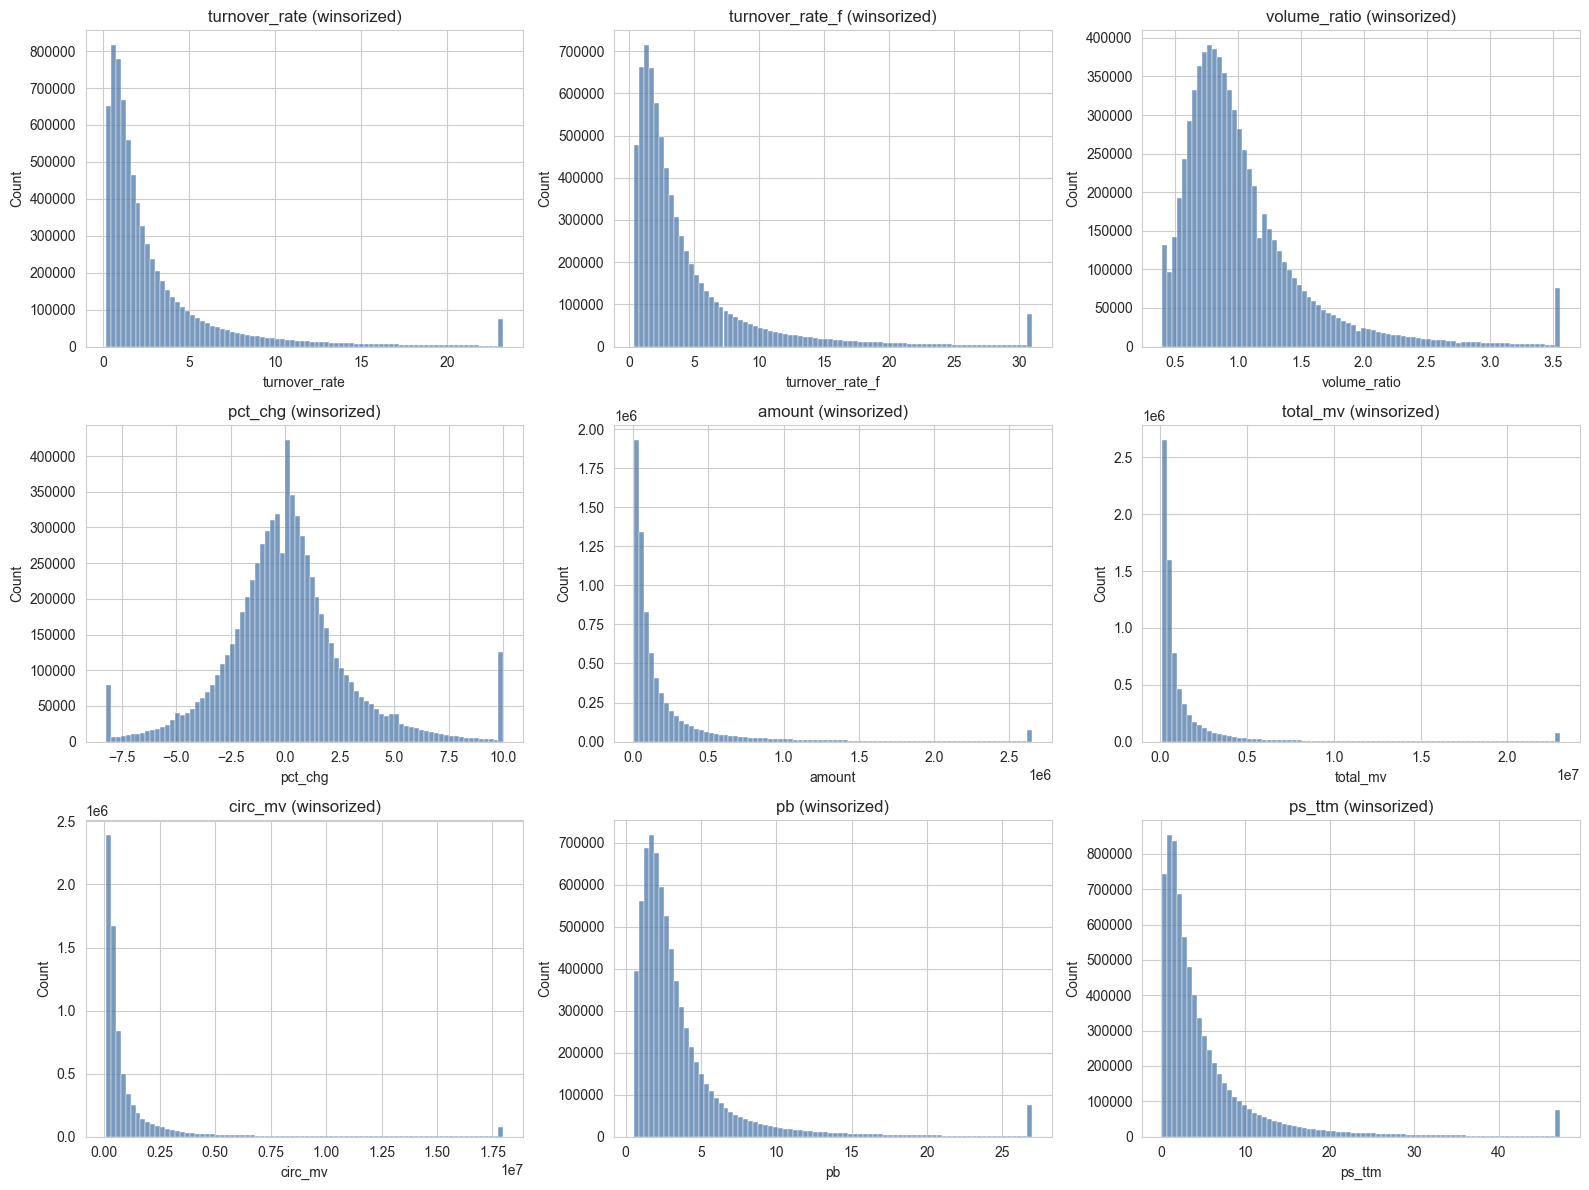

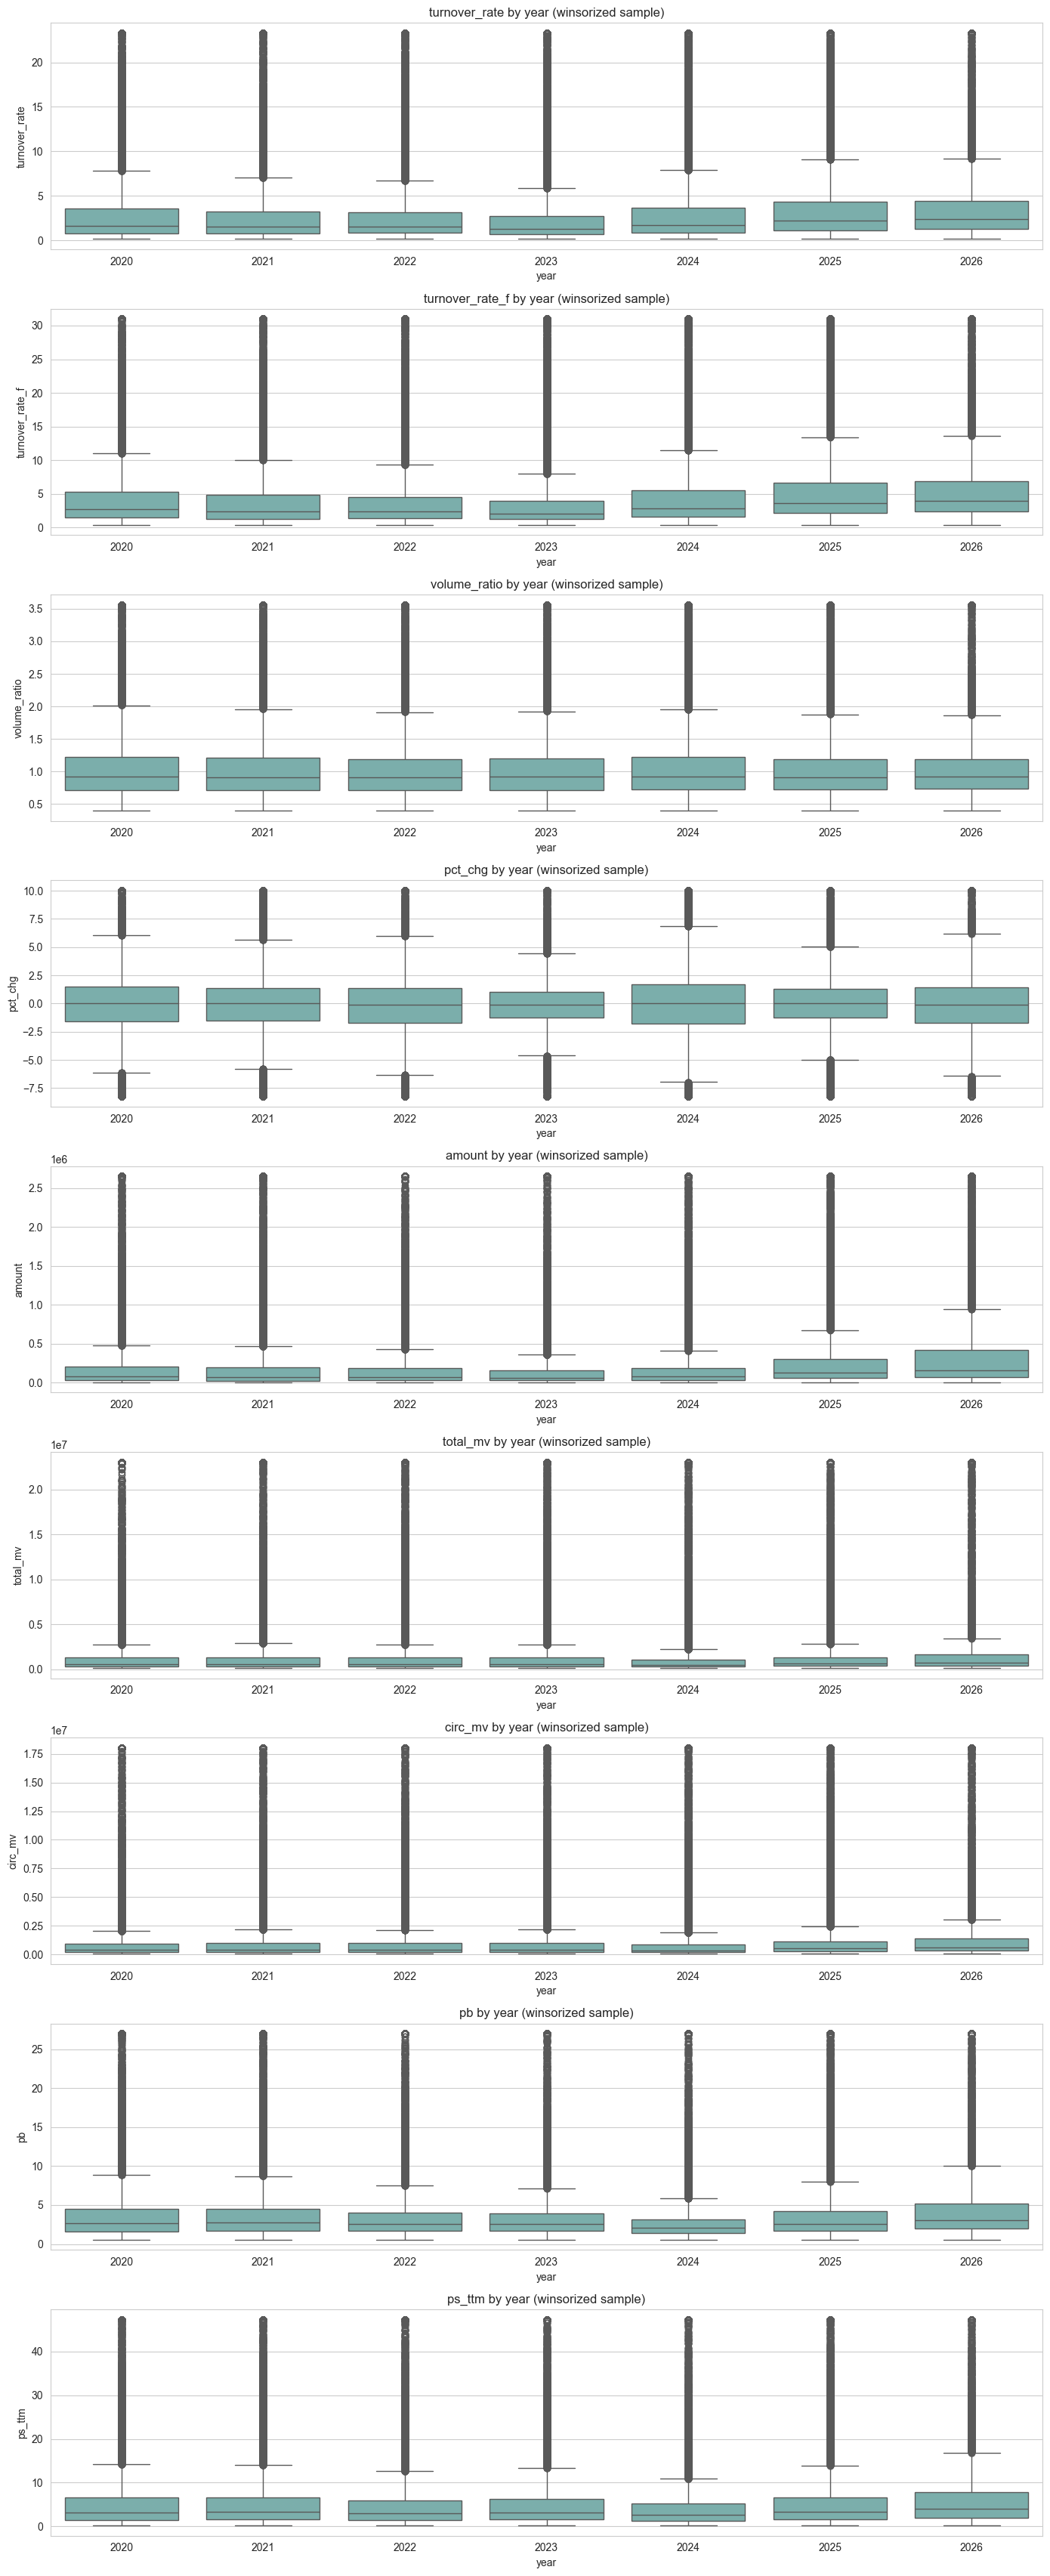

In [11]:
# 选出这一轮重点观察的字段，覆盖换手、量能、收益率、规模和估值几个方向
distribution_columns = [
    "turnover_rate",
    "turnover_rate_f",
    "volume_ratio",
    "pct_chg",
    "amount",
    "total_mv",
    "circ_mv",
    "pb",
    "ps_ttm",
]

# 构造截尾后的数据版本，避免极端值把主体分布完全压扁
winsorized_df = inspect_df.copy()
for col in distribution_columns:
    lower = winsorized_df[col].quantile(0.01)
    upper = winsorized_df[col].quantile(0.99)
    winsorized_df[col] = winsorized_df[col].clip(lower=lower, upper=upper)

# 输出本轮纳入分布研究的字段名单，方便回头对照哪些字段已经看过
print("distribution columns:", distribution_columns)

# 画截尾后的直方图，用来观察字段主体分布
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for idx, col in enumerate(distribution_columns):
    sns.histplot(winsorized_df[col].dropna(), bins=80, ax=axes[idx], color="#4C78A8")
    axes[idx].set_title(f"{col} (winsorized)")
for idx in range(len(distribution_columns), len(axes)):
    axes[idx].axis("off")
plt.tight_layout()
plt.show()

# 为了避免画箱线图时样本过大，这里抽样一部分数据来观察年度稳定性
boxplot_sample_df = winsorized_df.sample(min(200000, len(winsorized_df)), random_state=42)

# 画按年份分组的箱线图，观察这些字段在不同年份的中心和离散程度是否稳定
fig, axes = plt.subplots(len(distribution_columns), 1, figsize=(14, 3.8 * len(distribution_columns)))
for idx, col in enumerate(distribution_columns):
    sns.boxplot(data=boxplot_sample_df, x="year", y=col, ax=axes[idx], color="#72B7B2")
    axes[idx].set_title(f"{col} by year (winsorized sample)")
plt.tight_layout()
plt.show()


### 4.1 结果总结与后续研究启示

本节把 `turnover_rate`、`turnover_rate_f`、`volume_ratio`、`pct_chg`、`amount`、`total_mv`、`circ_mv`、`pb`、`ps_ttm` 放在一起观察。结果显示，这些字段并不是同一种性质的变量，后续不能用统一方式直接处理。

`turnover_rate` 和 `turnover_rate_f` 都呈明显右偏分布，且 2025、2026 年的整体水平明显抬升。这说明换手类字段有较强的市场环境漂移，后续更适合使用每日横截面排名、分位数或标准化值，而不是直接使用原始绝对值。`turnover_rate_f` 相比普通换手率数值更高，后续可以和 `turnover_rate` 同时进入候选池，但需要检查二者是否高度相关，避免重复表达同一类信号。

`volume_ratio` 的主体分布相对集中，多数样本围绕 1 附近，但右尾仍然明显。这个字段更像“相对历史成交活跃度”，跨年份稳定性好于换手率，适合作为异常放量、缩量、活跃度变化类因子的原材料。后续重点不是直接判断量比越高越好，而是通过分层收益检查看高量比是否代表趋势延续，还是代表短期过热。

`pct_chg` 分布以 0 附近为中心，两侧都有明显尾部，并且受到涨跌停制度影响，边界附近有堆积。这个字段单日噪声较强，不宜直接作为主因子，更适合继续派生为短期反转、阶段动量、连续上涨下跌、波动率等指标。

`amount`、`total_mv`、`circ_mv` 都呈严重右偏分布，并且 2025、2026 年的成交额和市值水平整体抬升。这些字段更容易代表流动性、规模和市场结构变化，而不一定是纯技术信号。后续如果使用它们，优先作为流动性过滤、规模分层或中性化控制变量；如果必须参与因子构建，应先做对数化和横截面标准化。

`pb` 和 `ps_ttm` 也存在右偏和年度漂移，尤其 2024 年偏低、2025-2026 年重新抬升。这类估值字段不属于本研究的主技术面信号，更适合作为风格控制或分层观察变量。后续如果某个技术因子在低估值或高估值股票中表现差异明显，需要把估值暴露单独识别出来。

对后续研究的直接指导是：第一，连续型原始字段不能直接裸用，至少要做截尾、日横截面排名或标准化；第二，换手率、量比更适合作为技术因子原材料；第三，成交额、市值、估值字段更适合作为控制变量；第四，真正值得继续挖掘的是这些字段的动态变化、相对位置和组合关系，而不是单纯比较原始数值大小。因此后面的 `4.2` 应重点验证这些字段分层后与未来收益之间是否存在稳定关系。

### 4.1.1 字段截尾与横截面标准化预处理

这一部分生成后续研究统一使用的 `factor_input_df`。连续型字段先做截尾，金额、市值和股本类字段先做 `log1p` 再截尾，最后按交易日生成 `0-1` 区间内的横截面分位排名字段。后续分层、热力图和市值/流动性分层研究优先使用这些处理后的字段。

In [ ]:
# Build a processed research table for later factor exploration.
factor_input_df = inspect_df.sort_values(["ts_code", "trade_date"]).copy()

# Forward returns are target variables, not factors. They are kept raw for evaluation.
factor_input_df["future_ret_5d"] = factor_input_df.groupby("ts_code")["close"].shift(-5) / factor_input_df["close"] - 1
factor_input_df["future_ret_10d"] = factor_input_df.groupby("ts_code")["close"].shift(-10) / factor_input_df["close"] - 1
factor_input_df["future_ret_20d"] = factor_input_df.groupby("ts_code")["close"].shift(-20) / factor_input_df["close"] - 1

# Price and volume derived fields used by later visual exploration.
factor_input_df["ret_1d"] = factor_input_df.groupby("ts_code")["close"].pct_change(1)
factor_input_df["ret_5d"] = factor_input_df.groupby("ts_code")["close"].pct_change(5)
factor_input_df["ret_10d"] = factor_input_df.groupby("ts_code")["close"].pct_change(10)
factor_input_df["ret_20d"] = factor_input_df.groupby("ts_code")["close"].pct_change(20)
factor_input_df["volatility_5d"] = factor_input_df.groupby("ts_code")["ret_1d"].transform(lambda x: x.rolling(5).std())
factor_input_df["volatility_20d"] = factor_input_df.groupby("ts_code")["ret_1d"].transform(lambda x: x.rolling(20).std())
factor_input_df["amplitude"] = (factor_input_df["high"] - factor_input_df["low"]) / factor_input_df["pre_close"].replace(0, np.nan)
factor_input_df["upper_shadow_ratio"] = (factor_input_df["high"] - factor_input_df[["open", "close"]].max(axis=1)) / factor_input_df["pre_close"].replace(0, np.nan)
factor_input_df["lower_shadow_ratio"] = (factor_input_df[["open", "close"]].min(axis=1) - factor_input_df["low"]) / factor_input_df["pre_close"].replace(0, np.nan)
factor_input_df["amount_ma20"] = factor_input_df.groupby("ts_code")["amount"].transform(lambda x: x.rolling(20).mean())
factor_input_df["amount_ratio_20d"] = factor_input_df["amount"] / factor_input_df["amount_ma20"]
factor_input_df["vol_ma20"] = factor_input_df.groupby("ts_code")["vol"].transform(lambda x: x.rolling(20).mean())
factor_input_df["vol_ratio_20d"] = factor_input_df["vol"] / factor_input_df["vol_ma20"]

# Log transforms reduce magnitude differences for amount, market cap and share scale fields.
log_source_columns = ["amount", "total_mv", "circ_mv", "free_share", "total_share", "circ_share"]
for col in log_source_columns:
    if col in factor_input_df.columns:
        factor_input_df[f"log_{col}"] = np.log1p(factor_input_df[col].clip(lower=0))

# Continuous fields to winsorize and convert into daily cross-sectional ranks.
preprocess_columns = [
    "turnover_rate",
    "turnover_rate_f",
    "volume_ratio",
    "pct_chg",
    "pb",
    "ps_ttm",
    "pe",
    "dv_ttm",
    "ret_5d",
    "ret_10d",
    "ret_20d",
    "volatility_5d",
    "volatility_20d",
    "amplitude",
    "upper_shadow_ratio",
    "lower_shadow_ratio",
    "amount_ratio_20d",
    "vol_ratio_20d",
    "log_amount",
    "log_total_mv",
    "log_circ_mv",
    "log_free_share",
    "log_total_share",
    "log_circ_share",
]
preprocess_columns = [col for col in preprocess_columns if col in factor_input_df.columns]

# Daily winsorization keeps extreme observations as high/low values, but limits their numeric dominance.
winsor_lower_q = 0.01
winsor_upper_q = 0.99
for col in preprocess_columns:
    lower = factor_input_df.groupby("trade_date")[col].transform(lambda x: x.quantile(winsor_lower_q))
    upper = factor_input_df.groupby("trade_date")[col].transform(lambda x: x.quantile(winsor_upper_q))
    factor_input_df[f"{col}_w"] = factor_input_df[col].clip(lower=lower, upper=upper)
    factor_input_df[f"{col}_rank"] = factor_input_df.groupby("trade_date")[f"{col}_w"].rank(pct=True, method="average")

# Named candidates used by the following sections.
processed_factor_columns = {
    "turnover_rate": "turnover_rate_rank",
    "turnover_rate_f": "turnover_rate_f_rank",
    "volume_ratio": "volume_ratio_rank",
    "pct_chg": "pct_chg_rank",
    "log_amount": "log_amount_rank",
    "log_total_mv": "log_total_mv_rank",
    "log_circ_mv": "log_circ_mv_rank",
    "pb": "pb_rank",
    "ps_ttm": "ps_ttm_rank",
    "ret_20d": "ret_20d_rank",
    "volatility_20d": "volatility_20d_rank",
}
processed_factor_columns = {k: v for k, v in processed_factor_columns.items() if v in factor_input_df.columns}

print("processed row count:", len(factor_input_df))
print("winsor quantile:", winsor_lower_q, winsor_upper_q)
print("processed factor columns:")
display(pd.DataFrame([{"raw_field": k, "processed_field": v} for k, v in processed_factor_columns.items()]))

display(factor_input_df[["ts_code", "trade_date"] + list(processed_factor_columns.values())].head())


### 4.1.1 预处理后研究表说明

`factor_input_df` 是在 `inspect_df` 基础上生成的新研究表，目的不是替代原表，而是把原始字段整理成更适合后续分层、打分和回测研究的输入形式。它保留了原始基础字段，同时新增了目标收益字段、价格成交量派生字段、对数化字段、截尾字段和横截面排名字段。

这张表中的字段可以按用途分成几类。第一类是原始基础字段，例如 `ts_code`（股票代码）、`trade_date`（交易日）、`open/high/low/close`（开高低收）、`vol/amount`（成交量与成交额）、`turnover_rate`、`volume_ratio`、`total_mv/circ_mv`、`pb/ps_ttm/pe/dv_ttm` 等。这些字段主要用于保留原始口径、回看样本、做个股案例观察，以及继续生成后续更复杂的技术指标。

第二类是目标收益字段，包括 `future_ret_5d`、`future_ret_10d`、`future_ret_20d`。它们的含义分别是“从今天收盘往后 5/10/20 个交易日的区间收益”。这几列不是因子输入，而是后续检验因子是否有预测性的目标变量。`4.2`、`4.3`、`4.4`、`4.5` 里的分层收益和热力图分析，都是用这些字段来判断某个信号是否对应更高或更低的未来收益。

第三类是价格与成交量派生字段，包括 `ret_1d`、`ret_5d`、`ret_10d`、`ret_20d`（短中期收益率）、`volatility_5d`、`volatility_20d`（短中期波动率）、`amplitude`（当日振幅）、`upper_shadow_ratio`、`lower_shadow_ratio`（上下影线占比）、`amount_ma20`、`amount_ratio_20d`、`vol_ma20`、`vol_ratio_20d` 等。这些字段主要为 `4.3` 和 `4.7` 服务：`4.3` 用它们研究量价组合与未来收益的二维关系，`4.7` 则专门检查这些派生技术信号本身的分布和稳定性。

第四类是对数化字段，包括 `log_amount`、`log_total_mv`、`log_circ_mv`、`log_free_share`、`log_total_share`、`log_circ_share`。这些字段是在原始金额、市值、股本基础上做 `log1p` 得到的，作用是压缩数量级差异，防止超大市值或超大成交额样本支配统计结果。`4.2` 和 `4.5` 会用这类字段的后续处理版本来做分层研究。

第五类是截尾字段，命名规则是 `*_w`，例如 `turnover_rate_w`、`ret_20d_w`、`log_total_mv_w`。它们表示该字段已经在每个交易日的横截面内做过 1% 到 99% 截尾处理。作用是保留高低极端区间的信息，同时降低极端值对后续统计结果的支配。

第六类是排名标准化字段，命名规则是 `*_rank`，例如 `turnover_rate_rank`、`volume_ratio_rank`、`pb_rank`、`ret_20d_rank`、`volatility_20d_rank`、`log_amount_rank` 等。这些字段表示某只股票在当天全市场横截面中的相对位置，数值固定在 `0-1` 区间内。它们是后续研究中最核心的输入。`4.2` 用它们做单字段分层，`4.3` 用它们做二维热力图，`4.4` 用 `turnover_rate_rank` 研究市场状态差异，`4.5` 用 `log_total_mv_rank` 和 `log_amount_rank` 做市值与流动性分层，`4.6` 会同时展示原始值和 rank 值的时间序列。

整体上，`factor_input_df` 是原始研究表和后续技术面因子研究之间的一层“研究输入层”。从这一节开始，除了特意回看原始值或做事件型分析的场景，后面的技术面研究应优先使用 `factor_input_df` 里的预处理字段。

### 4.2 单字段与未来收益的分层关系

这一部分不再只看少数几个字段，而是尽量对 `4.1.1` 预处理后生成的候选因子字段做全面分层检查。同时不只研究未来 `10` 日收益，而是同时对比未来 `5` 日、`10` 日、`20` 日收益。

核心目的是看：哪些字段在不同预测期下能形成稳定的分层梯度，哪些字段只在短期或中期有效，哪些字段则更可能只是噪声。


candidate field count: 24
candidate fields: ['amount_ratio_20d_rank', 'amplitude_rank', 'dv_ttm_rank', 'log_amount_rank', 'log_circ_mv_rank', 'log_circ_share_rank', 'log_free_share_rank', 'log_total_mv_rank', 'log_total_share_rank', 'lower_shadow_ratio_rank', 'pb_rank', 'pct_chg_rank', 'pe_rank', 'ps_ttm_rank', 'ret_10d_rank', 'ret_20d_rank', 'ret_5d_rank', 'turnover_rate_f_rank', 'turnover_rate_rank', 'upper_shadow_ratio_rank', 'vol_ratio_20d_rank', 'volatility_20d_rank', 'volatility_5d_rank', 'volume_ratio_rank']
target return horizons: ['future_ret_5d', 'future_ret_10d', 'future_ret_20d']


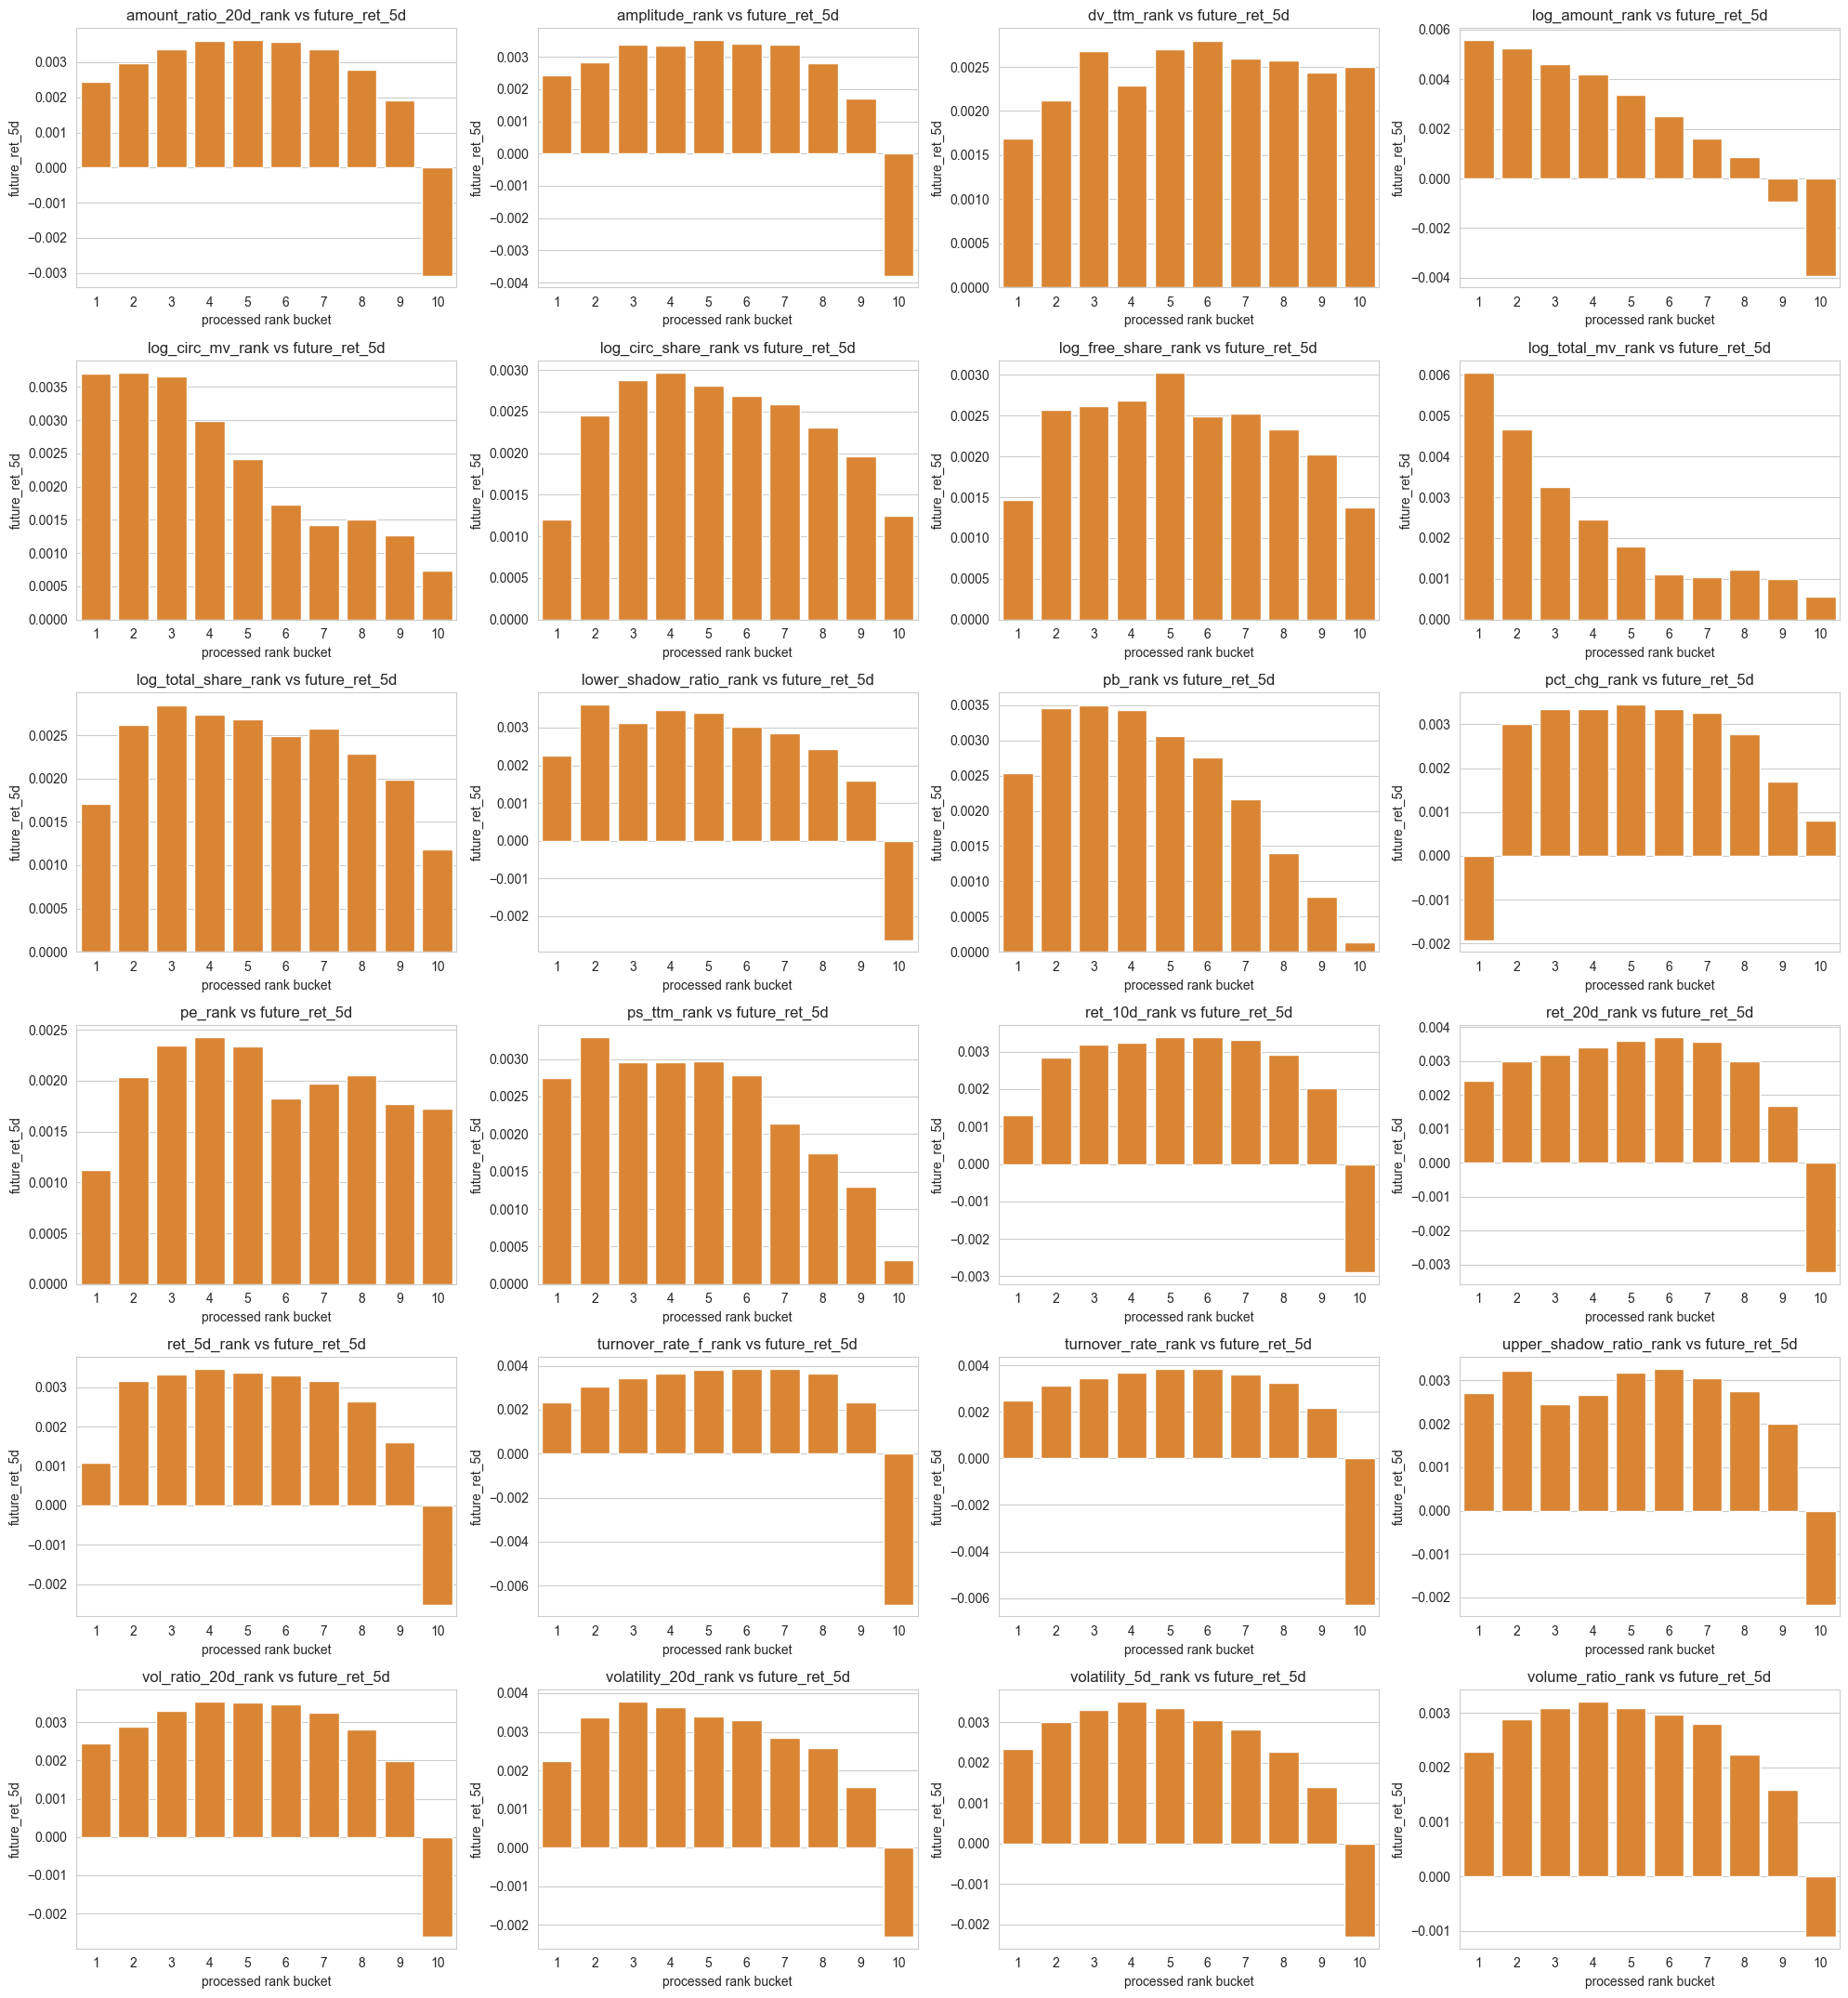

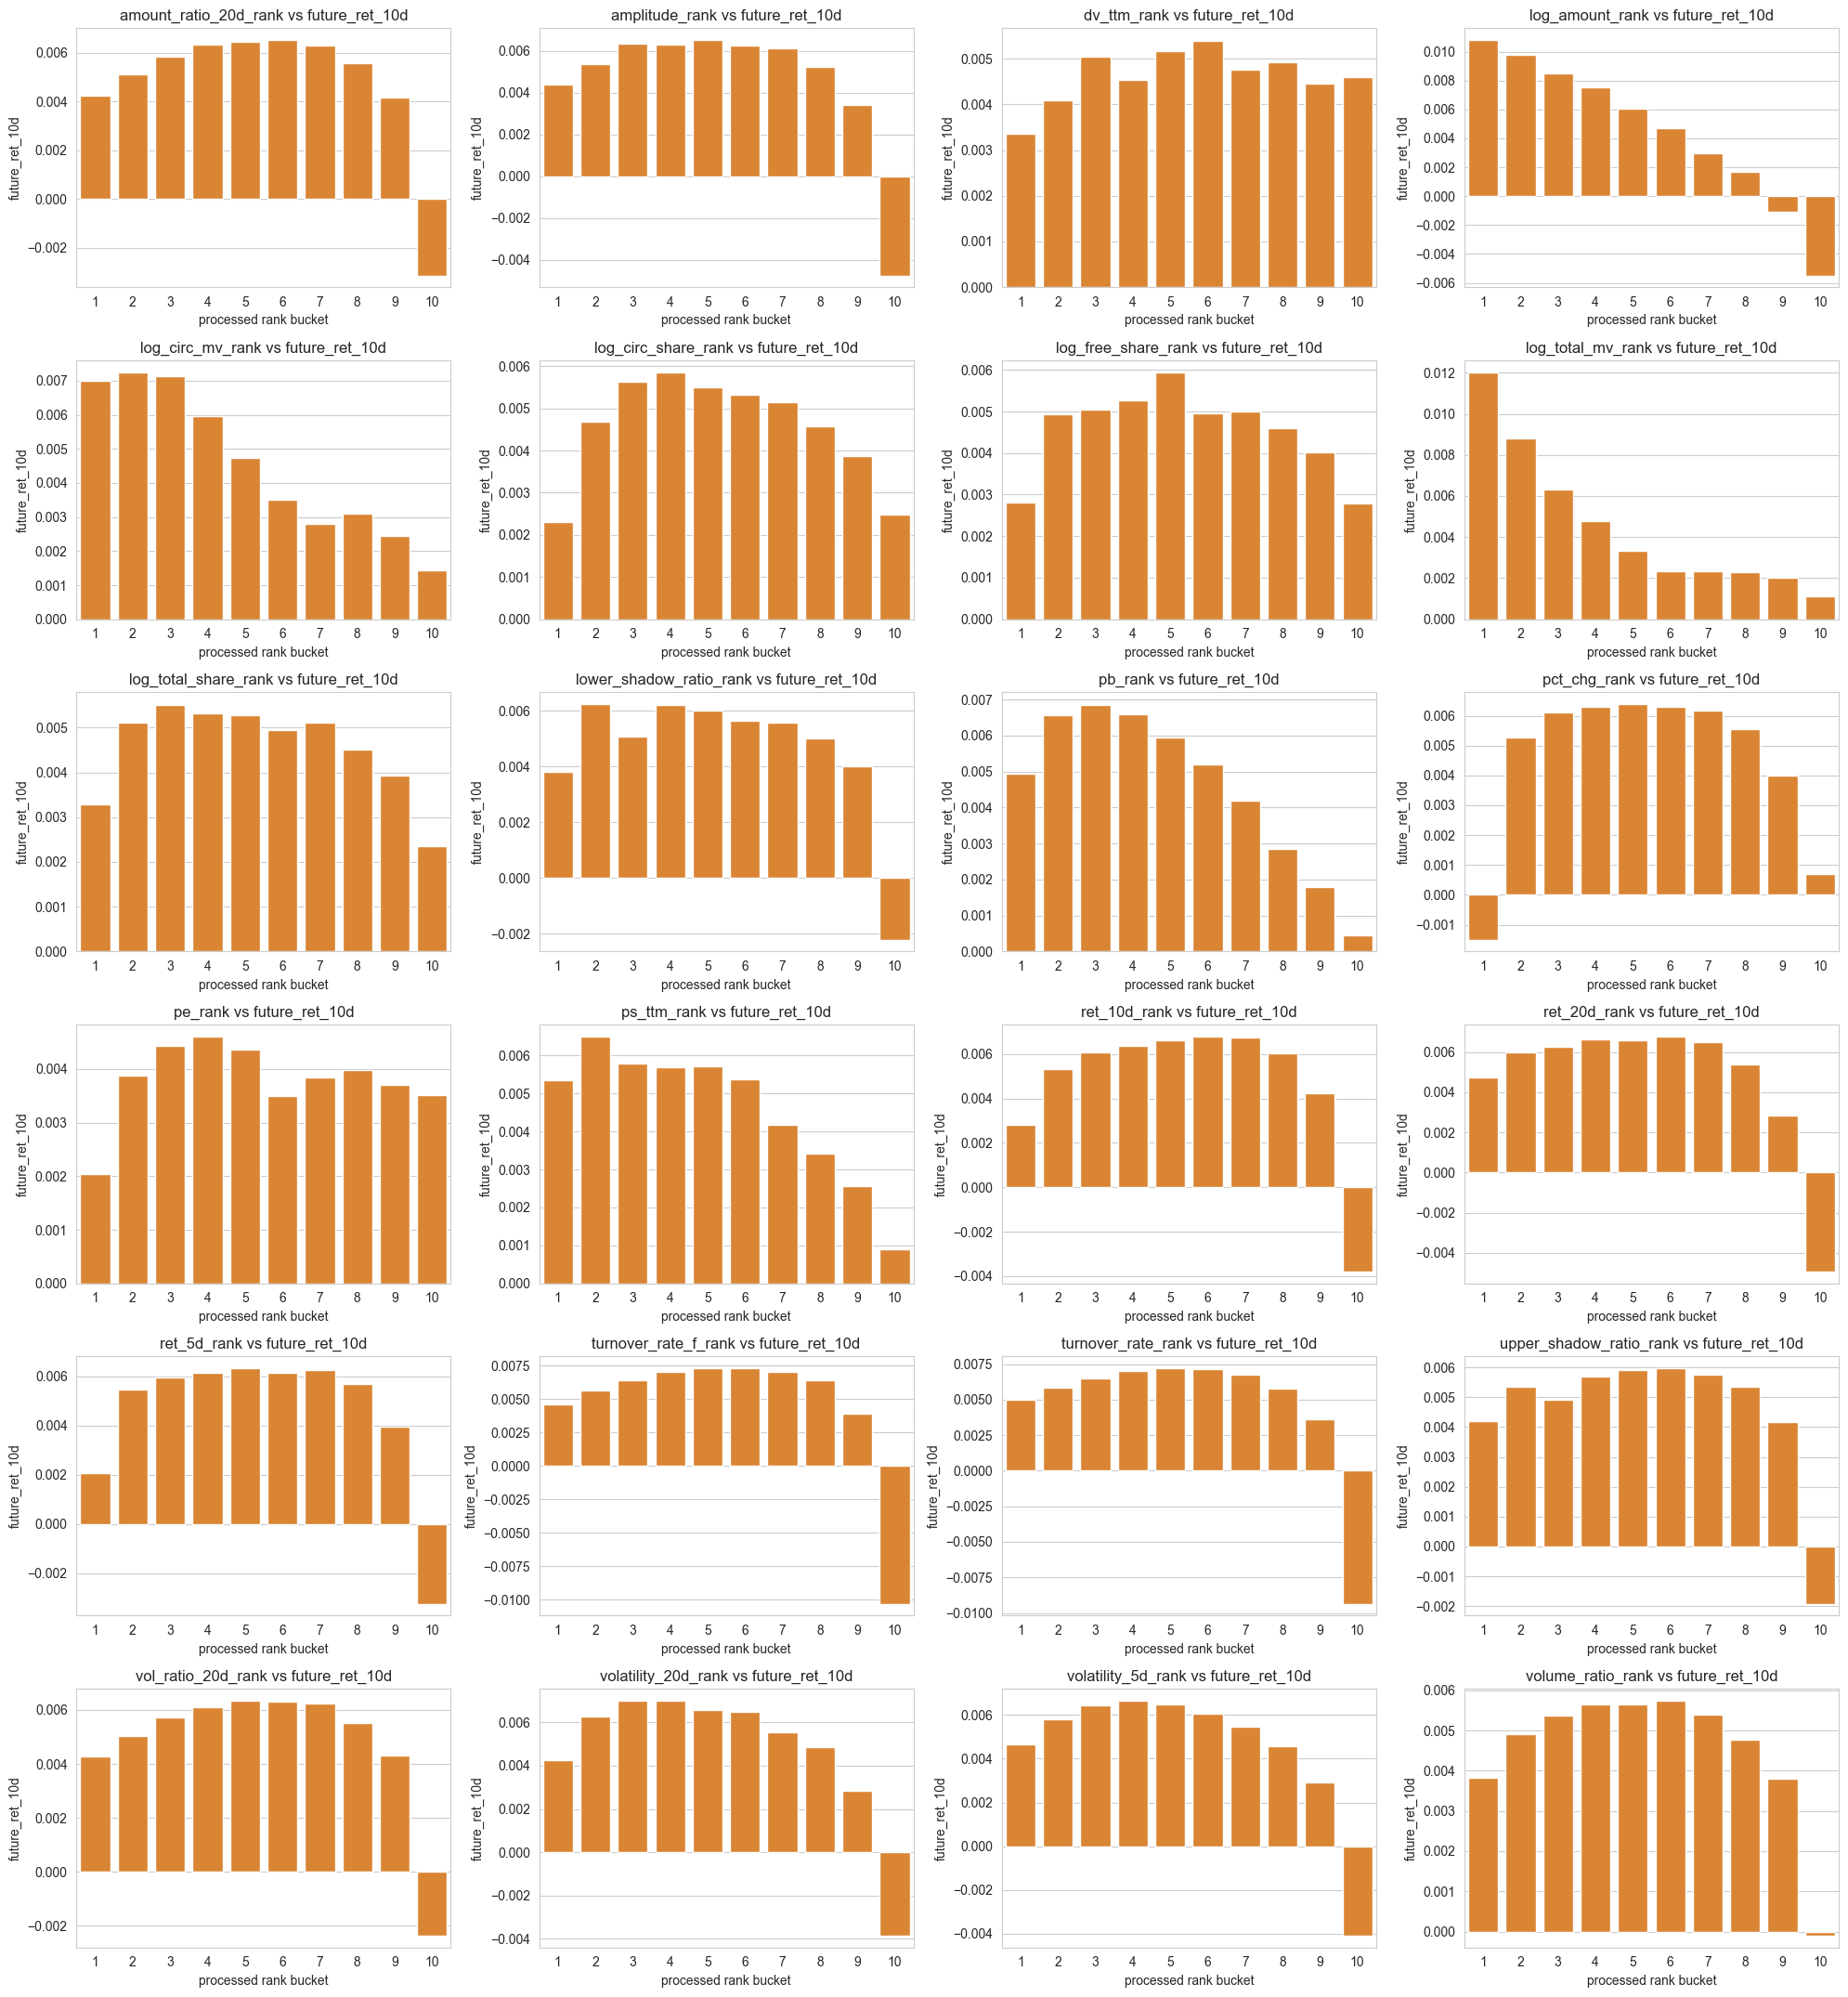

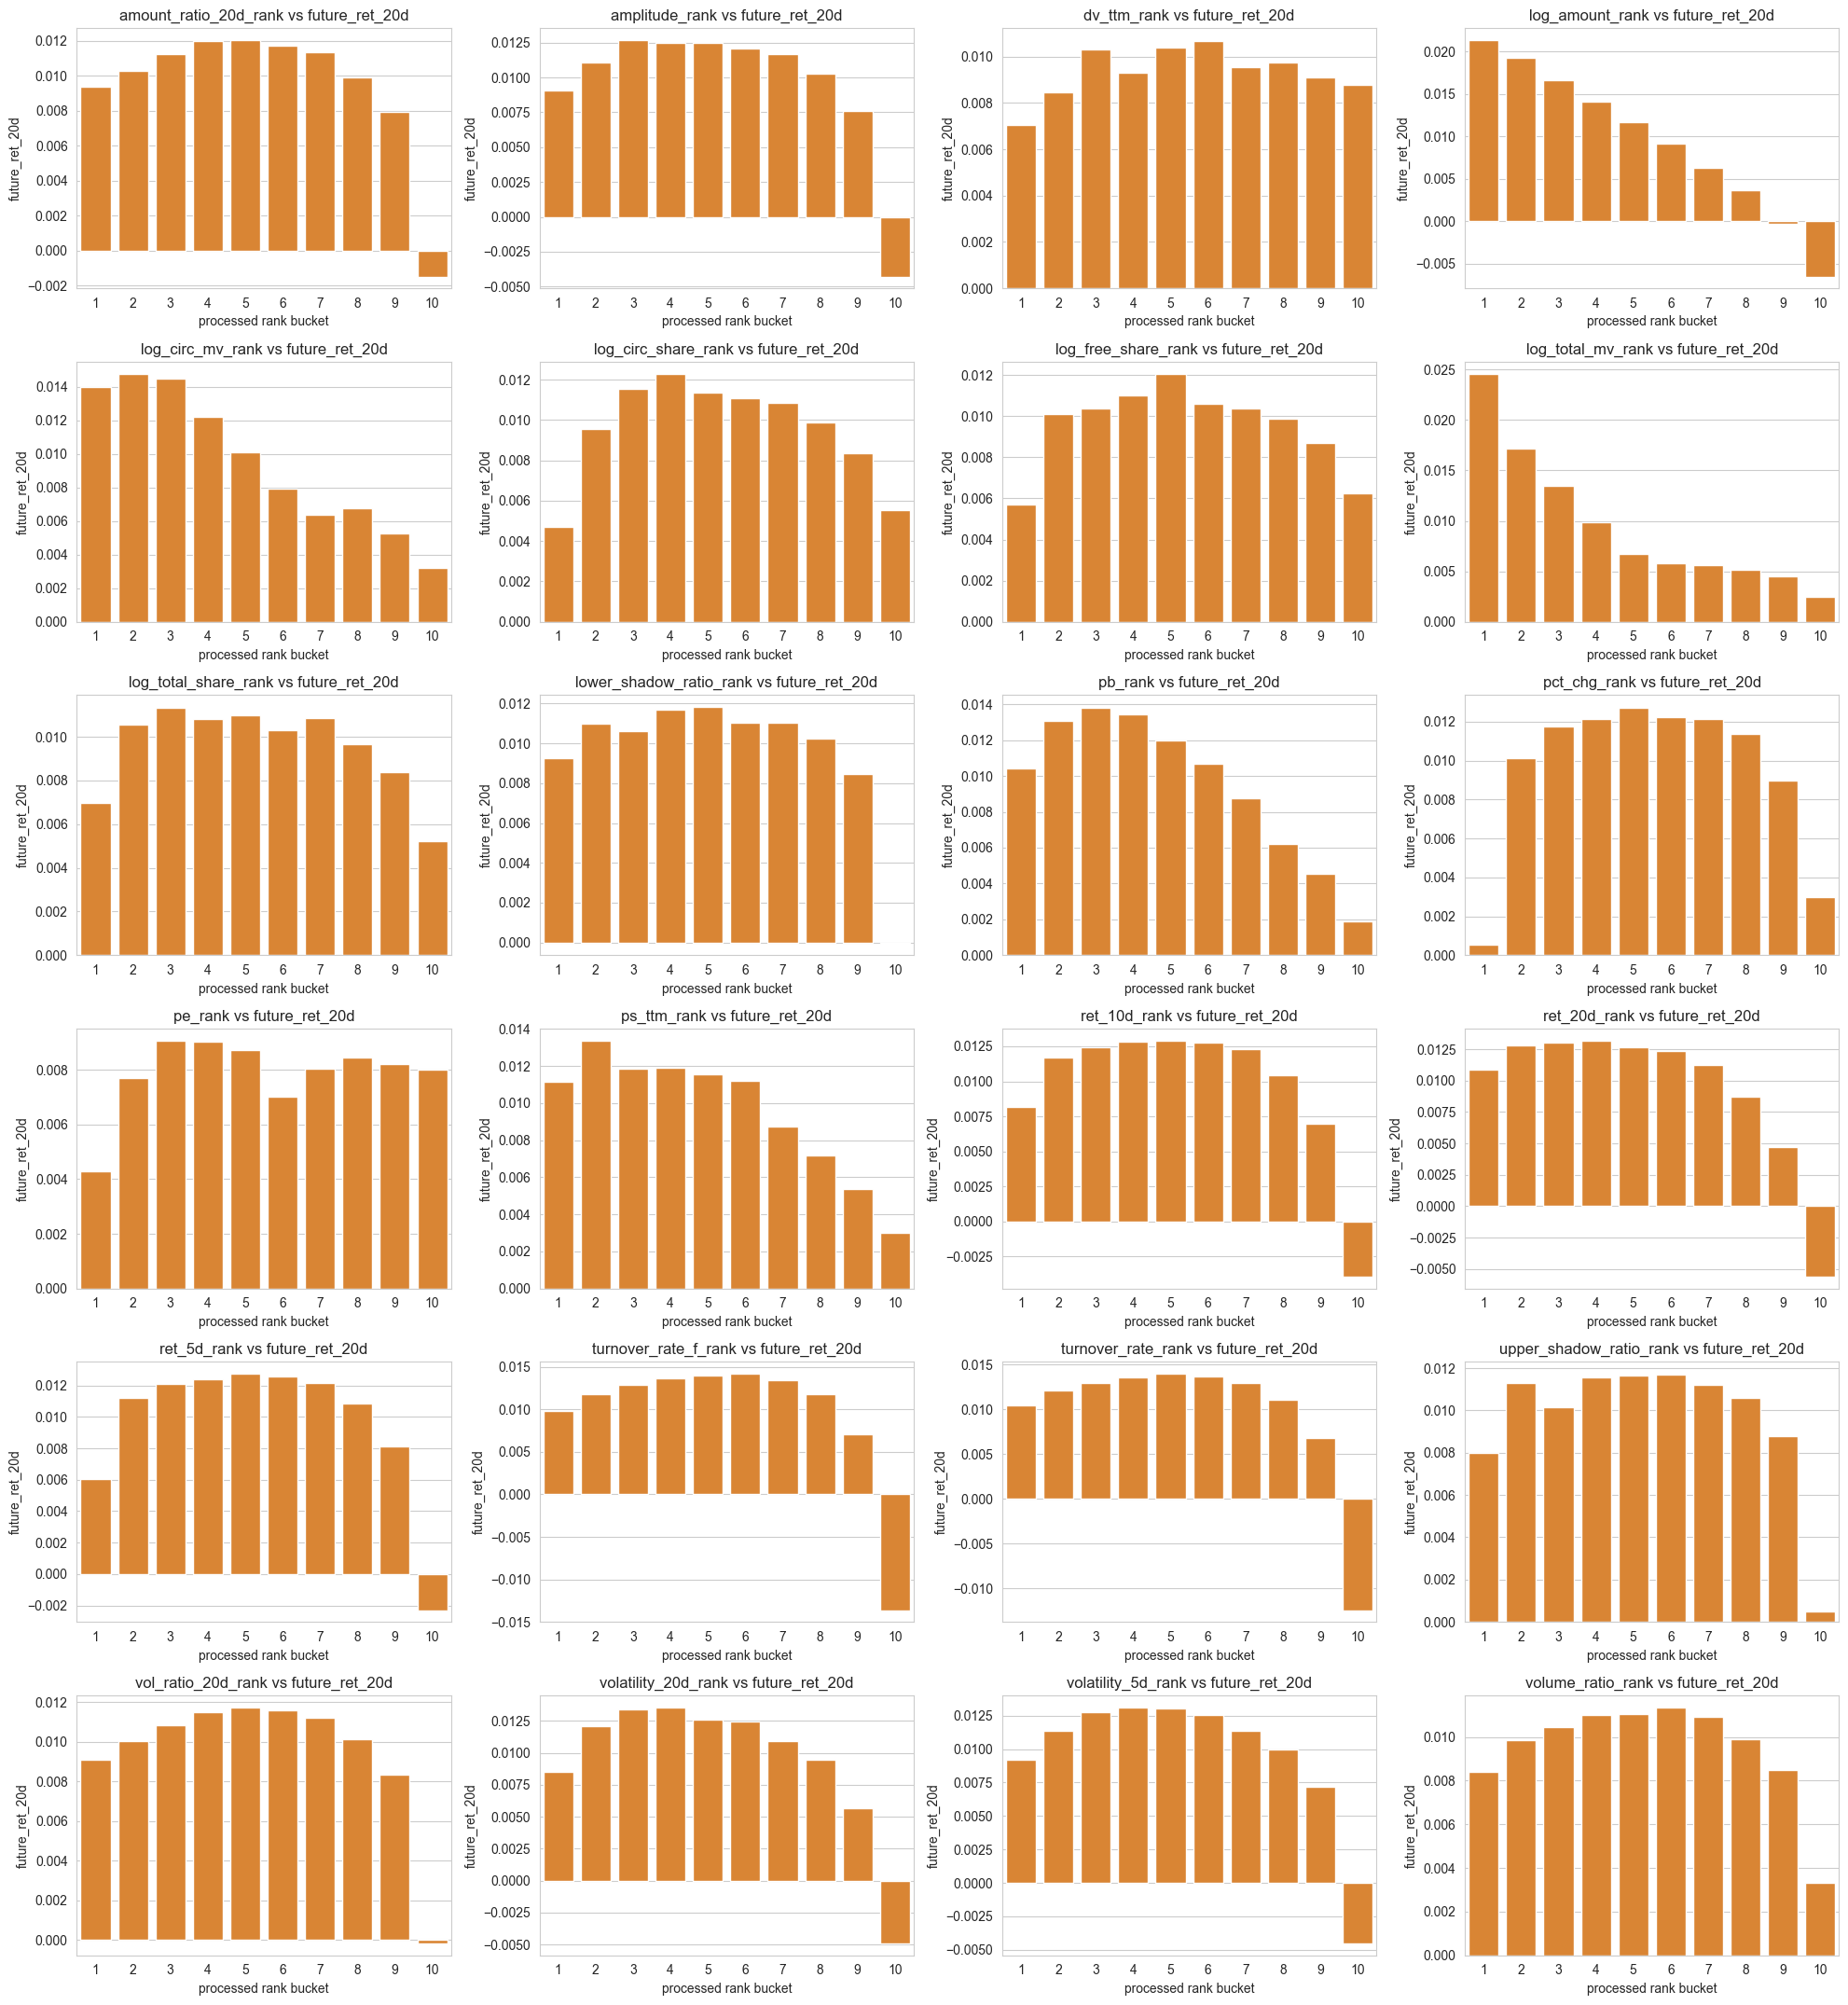

,factor,target_return,bucket_1_ret,bucket_10_ret,spread_10_minus_1,bucket_order_corr,min_bucket_count,max_bucket_count
0,pct_chg_rank,future_ret_10d,-0.001499,0.000697,0.002196,0.050850,726712,730775
1,pe_rank,future_ret_10d,0.002039,0.003512,0.001472,0.168418,598664,599795
2,dv_ttm_rank,future_ret_10d,0.003350,0.004585,0.001235,0.435854,489103,490858
3,log_circ_share_rank,future_ret_10d,0.002307,0.002473,0.000166,-0.170196,728669,729670
4,log_free_share_rank,future_ret_10d,0.002803,0.002787,-0.000016,-0.187569,728580,729558
...,...,...,...,...,...,...,...,...
67,ret_20d_rank,future_ret_5d,0.002412,-0.003229,-0.005641,-0.530016,718593,720769
68,amplitude_rank,future_ret_5d,0.002442,-0.003784,-0.006227,-0.554757,730639,734234
69,turnover_rate_rank,future_ret_5d,0.002477,-0.006273,-0.008750,-0.518891,731282,732474
70,turnover_rate_f_rank,future_ret_5d,0.002327,-0.006865,-0.009193,-0.482279,731145,732494


,bucket,future_ret_5d,sample_count,factor,target_return,future_ret_10d,future_ret_20d
0,1,0.002439,715438,amount_ratio_20d_rank,future_ret_5d,NaN,NaN
1,2,0.002981,716802,amount_ratio_20d_rank,future_ret_5d,NaN,NaN
2,3,0.003357,716737,amount_ratio_20d_rank,future_ret_5d,NaN,NaN
3,4,0.003603,716856,amount_ratio_20d_rank,future_ret_5d,NaN,NaN
4,5,0.003629,716932,amount_ratio_20d_rank,future_ret_5d,NaN,NaN
...,...,...,...,...,...,...,...
715,6,NaN,723893,volume_ratio_rank,future_ret_20d,NaN,0.011340
716,7,NaN,723589,volume_ratio_rank,future_ret_20d,NaN,0.010932
717,8,NaN,722691,volume_ratio_rank,future_ret_20d,NaN,0.009898
718,9,NaN,722512,volume_ratio_rank,future_ret_20d,NaN,0.008499


In [13]:
# Use processed 0-1 daily rank fields to test as many candidate fields as possible against multiple return horizons.
analysis_df = factor_input_df.copy()

target_return_columns = [
    "future_ret_5d",
    "future_ret_10d",
    "future_ret_20d",
]
target_return_columns = [col for col in target_return_columns if col in analysis_df.columns]

# Automatically include all processed factor columns generated in 4.1.1.
candidate_columns = sorted(
    [
        col
        for col in analysis_df.columns
        if col.endswith("_rank")
        and not col.startswith("future_")
        and analysis_df[col].notna().sum() > 0
    ]
)

print("candidate field count:", len(candidate_columns))
print("candidate fields:", candidate_columns)
print("target return horizons:", target_return_columns)

layering_results = []
for target_return_col in target_return_columns:
    for factor_col in candidate_columns:
        temp = analysis_df[["trade_date", factor_col, target_return_col]].dropna().copy()
        temp["bucket"] = np.ceil(temp[factor_col] * 10).clip(1, 10).astype(int)
        grouped = temp.groupby("bucket")[target_return_col].agg(["mean", "count"]).reset_index()
        grouped = grouped.rename(columns={"mean": target_return_col, "count": "sample_count"})
        grouped["factor"] = factor_col
        grouped["target_return"] = target_return_col
        layering_results.append(grouped)

layering_df = pd.concat(layering_results, ignore_index=True)

summary_rows = []
for target_return_col in target_return_columns:
    for factor_col in candidate_columns:
        temp = layering_df[(layering_df["factor"] == factor_col) & (layering_df["target_return"] == target_return_col)].copy()
        if temp.empty:
            continue
        bucket_1_ret = temp.loc[temp["bucket"] == 1, target_return_col].iloc[0] if (temp["bucket"] == 1).any() else np.nan
        bucket_10_ret = temp.loc[temp["bucket"] == 10, target_return_col].iloc[0] if (temp["bucket"] == 10).any() else np.nan
        bucket_order_corr = temp[["bucket", target_return_col]].corr().iloc[0, 1]
        min_bucket_count = temp["sample_count"].min() if "sample_count" in temp.columns else np.nan
        max_bucket_count = temp["sample_count"].max() if "sample_count" in temp.columns else np.nan
        summary_rows.append({
            "factor": factor_col,
            "target_return": target_return_col,
            "bucket_1_ret": bucket_1_ret,
            "bucket_10_ret": bucket_10_ret,
            "spread_10_minus_1": bucket_10_ret - bucket_1_ret,
            "bucket_order_corr": bucket_order_corr,
            "min_bucket_count": min_bucket_count,
            "max_bucket_count": max_bucket_count,
        })

layering_summary_df = pd.DataFrame(summary_rows).sort_values(["target_return", "spread_10_minus_1"], ascending=[True, False]).reset_index(drop=True)

ncols = 4
for target_return_col in target_return_columns:
    plot_target_df = layering_df[layering_df["target_return"] == target_return_col]
    nrows = int(np.ceil(len(candidate_columns) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3.6 * nrows))
    axes = np.array(axes).reshape(-1)
    for idx, factor_col in enumerate(candidate_columns):
        plot_df = plot_target_df[plot_target_df["factor"] == factor_col]
        sns.barplot(data=plot_df, x="bucket", y=target_return_col, ax=axes[idx], color="#F58518")
        axes[idx].set_title(f"{factor_col} vs {target_return_col}")
        axes[idx].set_xlabel("processed rank bucket")
        axes[idx].set_ylabel(target_return_col)
    for idx in range(len(candidate_columns), len(axes)):
        axes[idx].axis("off")
    plt.tight_layout()
    plt.show()

display(layering_summary_df)
display(layering_df)


### 4.2 结果总结与后续研究启示

本部分研究的是：把单个候选字段按日横截面分位排名后分成 `10` 组，观察每一组股票未来 `5` 日、`10` 日、`20` 日的平均收益，从而判断该字段是否具备稳定的分层能力。这里的结果是基于“全样本池化”得到的，也就是把所有交易日、所有股票中落入同一分组的样本合并后，再计算未来收益均值。

从整体结果看，大部分字段都不是简单的“越大越好”或“越小越好”，而是更常见地呈现出“中间较优、极端最差”的非线性结构，尤其是第 `10` 组经常明显走弱。这说明很多技术面字段不能直接裸做线性打分，更适合进一步研究它们的中间区间、极端区间以及与其他字段联动后的表现。

第一类值得重点关注的是“热度/拥挤/过热”相关字段，包括 `turnover_rate_rank`、`turnover_rate_f_rank`、`log_amount_rank`、`amount_ratio_20d_rank`、`vol_ratio_20d_rank`、`volume_ratio_rank`、`amplitude_rank`、`volatility_5d_rank`、`volatility_20d_rank` 以及 `ret_5d_rank`、`ret_10d_rank`、`ret_20d_rank`。这些字段大多表现为：从低组到中高组，未来收益先改善，但一旦进入最极端的高分组，未来收益明显恶化，部分组别甚至直接转负。这表明 A 股市场中“过热”“过度拥挤”“极端放量”“极端强势”往往不是继续上涨的信号，反而更可能对应短中期回落风险。后续构造因子时，这类字段更适合做极端值惩罚、中间区间偏好，或者作为过热过滤条件，而不适合直接设定为“值越大分越高”。

第二类是规模相关字段，包括 `log_total_mv_rank`、`log_circ_mv_rank`、`log_total_share_rank`、`log_circ_share_rank`、`log_free_share_rank`。这些字段整体呈现较明显的反向关系，即低分组往往未来收益更高，高分组未来收益更弱，说明样本期内小市值、小流通盘股票的收益弹性明显更强。这类结果很重要，但也要警惕把风格暴露误认为技术因子有效性。后续所有技术因子研究都应考虑加入市值分层、规模控制或中性化检验，否则容易把“小票效应”误当成技术信号本身的预测能力。

第三类是估值相关字段，包括 `pb_rank`、`ps_ttm_rank`、`pe_rank`、`dv_ttm_rank`。其中 `pb_rank` 和 `ps_ttm_rank` 的反向特征相对更清晰，说明较低估值股票在样本期内整体表现更优；`pe_rank` 也有一定结构，但线性关系不如 `pb` 和 `ps_ttm` 稳定；`dv_ttm_rank` 虽然整体为正收益区间，但更像弱风格特征，而不是很强的单字段预测信号。因此估值类字段更适合作为组合条件、风格辅助变量或控制变量，而不一定是本轮技术面挖掘的主轴。

第四类是 K 线状态和价格行为字段，包括 `upper_shadow_ratio_rank`、`lower_shadow_ratio_rank`、`amplitude_rank` 等。它们整体有一定分层信息，但多数也呈现非线性结构，即中间组相对较优、极端组较差。这说明单日形态类字段可以作为辅助信号，用来刻画当天交易状态、资金博弈强弱和短期情绪位置，但暂时不适合直接作为全市场排序的主因子，更适合和动量、换手、成交额等字段做组合研究。

从预测期对比来看，`future_ret_5d` 的结果最敏感，很多“过热后回落”的特征在 `5` 日维度上表现最明显；`future_ret_10d` 的分层结构通常最清晰，适合作为当前阶段筛选单字段有效性的核心窗口；`future_ret_20d` 虽然很多关系仍然存在，但更偏向“中间平台 + 极端尾部恶化”的结构，说明不少字段反映的是中短期行为特征，而不是长期稳定趋势因子。

基于本部分结果，后续研究有几条明确方向。第一，后续不应只做单字段线性打分，而应重点考虑非线性构造方式，例如中段加分、极端扣分或极端过滤。第二，应重点研究“动量 + 热度”“动量 + 波动”“动量 + K 线状态”这类二维组合关系，判断哪些状态组合对应更优的未来收益。第三，市值和流动性风格对结果影响较大，后续需要在不同规模层级中验证技术信号是否依然有效。第四，`4.2` 目前使用的是全样本池化的分层平均结果，适合用于初筛候选字段；如果后续需要进一步验证稳定性，还应补充按交易日等权的分层收益分析以及多空 spread 的时间序列表现。

综合来看，`4.2` 已经给出一个比较明确的信号：当前样本中最值得继续深挖的，并不是“数值越大越好”的单向字段，而是那些能够刻画市场过热、拥挤、强弱切换和规模风格交互关系的字段。后续的重点应从“找最强单字段”转向“找最有解释力的状态组合”。

### 4.3 量价联动的二维关系

这一部分主要研究两个字段联动后与未来收益之间的关系。单字段研究只能回答“某一个字段高或低时，未来收益大致怎样”，但真实市场中很多信号都不是独立起作用的，而是取决于它和其他状态变量的搭配关系。

本部分重点观察以下几类二维组合：中期动量和换手、中期动量和放量程度、中期动量和波动率、中期动量和振幅、短期动量和中期动量，以及中期动量和市值。研究目标是判断：哪些状态组合对应更优的未来收益，哪些状态组合虽然单字段看起来不差，但在与另一类状态叠加后会表现出明显的过热、拥挤或反转风险。

这里依然使用 `4.1.1` 中构造好的预处理字段，即对连续字段先做截尾，再按交易日做横截面分位排名。每个维度都分成 `5` 桶，最终生成 `5 x 5` 的热力图。热力图中的每个格子，表示某两个字段同时落在对应分组时，这批样本未来 `10` 日收益的平均值。颜色越偏红绿极端，说明该状态组合和未来收益之间的关系越明显；颜色越接近中性，说明该组合的区分能力越弱。

为了便于后续复盘和让我直接读取结果，这一部分会自动把热力图保存到 `outputs` 文件夹。同时，每一组二维组合都会额外输出一张平均收益表和一张样本量表，后续解读时不仅看哪个区域收益高，还要看该区域样本量是否足够大，避免被局部小样本误导。

这一部分的作用，不是直接产出最终因子，而是帮助后续确认哪些字段适合做组合、哪些区域需要避开、哪些二维状态可以进一步转化为规则型因子或复合打分项。

heatmap pair count: 6
heatmap pairs:
 - ret_20d_rank x turnover_rate_rank -> future_ret_10d
 - ret_20d_rank x amount_ratio_20d_rank -> future_ret_10d
 - ret_20d_rank x volatility_20d_rank -> future_ret_10d
 - ret_20d_rank x amplitude_rank -> future_ret_10d
 - ret_5d_rank x ret_20d_rank -> future_ret_10d
 - ret_20d_rank x log_total_mv_rank -> future_ret_10d
saved heatmap figure to: C:\Users\李申\Desktop\Quant Project\research\ashare_sse_szse_technical_factor_mining_01\outputs\4_3_extracted\cell_4_3_latest_output.png


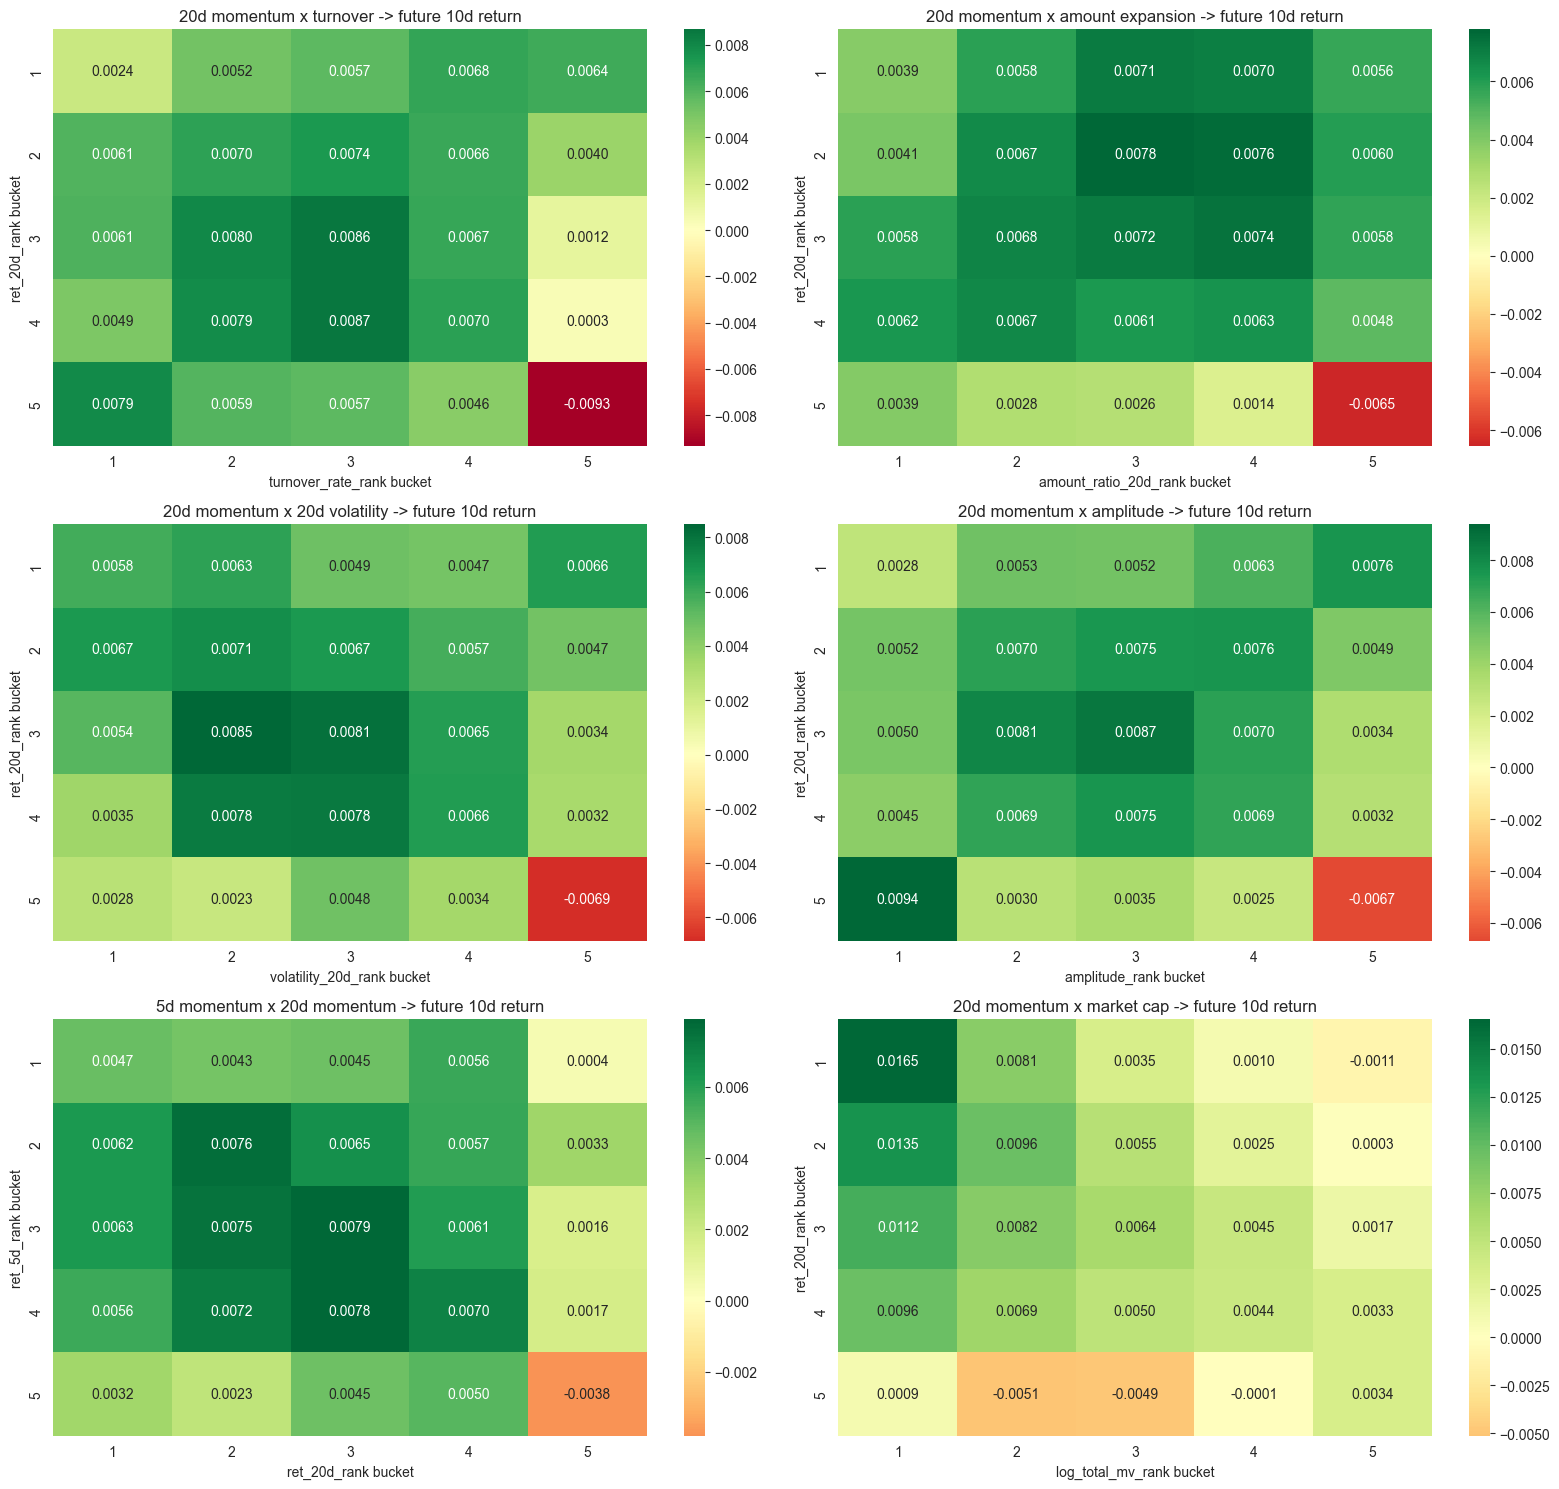


=== 20d momentum x turnover -> future 10d return ===
mean future return heatmap:


y_bucket,1,2,3,4,5
x_bucket,,,,,
1,0.002440,0.005158,0.005726,0.006819,0.006448
2,0.006062,0.006956,0.007395,0.006593,0.003994
3,0.006111,0.007978,0.008628,0.006740,0.001153
4,0.004883,0.007886,0.008666,0.007036,0.000328
5,0.007900,0.005938,0.005737,0.004562,-0.009309


sample count heatmap:


y_bucket,1,2,3,4,5
x_bucket,,,,,
1,259309,295415,320983,323302,233530
2,396042,359534,304999,240196,134313
3,387253,350659,303101,245358,148793
4,276868,288283,305619,311210,252672
5,120078,147776,206243,319824,640158



=== 20d momentum x amount expansion -> future 10d return ===
mean future return heatmap:


...

y_bucket,1,2,3,4,5
x_bucket,,,,,
1,540051,288688,208188,191069,196045
2,383501,406424,307297,212375,126507
3,257614,378981,382604,276883,141034
4,168149,258826,366170,401571,242034
5,81687,101524,170174,351735,725364



=== 20d momentum x market cap -> future 10d return ===
mean future return heatmap:


y_bucket,1,2,3,4,5
x_bucket,,,,,
1,0.016525,0.008061,0.003457,0.000978,-0.001128
2,0.013502,0.009587,0.005466,0.002480,0.000251
3,0.011204,0.008220,0.006450,0.004499,0.001715
4,0.009586,0.006941,0.005040,0.004364,0.003339
5,0.000913,-0.005118,-0.004945,-0.000051,0.003382


sample count heatmap:


y_bucket,1,2,3,4,5
x_bucket,,,,,
1,272502,279023,287786,297783,295445
2,301540,300961,285669,279114,267800
3,326735,301949,281805,267327,257348
4,313913,287922,280414,274036,278367
5,218016,263623,297292,316385,338763


In [15]:
# 扩展后的二维关系研究：基于预处理后的 rank 字段，观察不同状态组合对应的未来 10 日收益
analysis_df = factor_input_df.copy()

# 指定 4.3 图片输出目录，统一保存到 outputs/4_3_extracted 下
HEATMAP_OUTPUT_DIR = OUTPUT_DIR / "4_3_extracted"
HEATMAP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 每个元组分别表示：横轴字段、纵轴字段、目标收益字段、图标题
heatmap_specs = [
    ("ret_20d_rank", "turnover_rate_rank", "future_ret_10d", "20d momentum x turnover -> future 10d return"),
    ("ret_20d_rank", "amount_ratio_20d_rank", "future_ret_10d", "20d momentum x amount expansion -> future 10d return"),
    ("ret_20d_rank", "volatility_20d_rank", "future_ret_10d", "20d momentum x 20d volatility -> future 10d return"),
    ("ret_20d_rank", "amplitude_rank", "future_ret_10d", "20d momentum x amplitude -> future 10d return"),
    ("ret_5d_rank", "ret_20d_rank", "future_ret_10d", "5d momentum x 20d momentum -> future 10d return"),
    ("ret_20d_rank", "log_total_mv_rank", "future_ret_10d", "20d momentum x market cap -> future 10d return"),
]

# 只保留当前研究表中确实存在的字段组合，避免因为字段缺失直接报错
available_specs = [
    spec for spec in heatmap_specs
    if all(col in analysis_df.columns for col in spec[:3])
]

print("heatmap pair count:", len(available_specs))
print("heatmap pairs:")
for spec in available_specs:
    print(" -", spec[0], "x", spec[1], "->", spec[2])

# 用字典保存每一组组合关系对应的收益热力表和样本量热力表
heatmap_results = {}
sample_count_results = {}

for x_col, y_col, target_col, title in available_specs:
    temp = analysis_df[["trade_date", x_col, y_col, target_col]].dropna().copy()

    # 把两个维度都分成 5 组，便于观察二维区域
    temp["x_bucket"] = np.ceil(temp[x_col] * 5).clip(1, 5).astype(int)
    temp["y_bucket"] = np.ceil(temp[y_col] * 5).clip(1, 5).astype(int)

    # 计算每个二维分组下未来收益的平均值
    pivot_mean = temp.groupby(["x_bucket", "y_bucket"])[target_col].mean().unstack()

    # 同时保留每个格子的样本量，方便判断极端结果是否可靠
    pivot_count = temp.groupby(["x_bucket", "y_bucket"])[target_col].count().unstack()

    heatmap_results[(x_col, y_col, target_col, title)] = pivot_mean
    sample_count_results[(x_col, y_col, target_col, title)] = pivot_count

# 统一画成 2 列布局，方便一屏比较不同组合
ncols = 2
nrows = int(np.ceil(len(available_specs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
axes = np.array(axes).reshape(-1)

for idx, spec in enumerate(available_specs):
    x_col, y_col, target_col, title = spec
    pivot_mean = heatmap_results[spec]

    sns.heatmap(
        pivot_mean,
        annot=True,
        fmt=".4f",
        cmap="RdYlGn",
        center=0,
        ax=axes[idx],
    )
    axes[idx].set_title(title)
    axes[idx].set_xlabel(f"{y_col} bucket")
    axes[idx].set_ylabel(f"{x_col} bucket")

# 如果图位比组合数多，就把多余的坐标轴隐藏
for idx in range(len(available_specs), len(axes)):
    axes[idx].axis("off")

plt.tight_layout()

# 保存热力图到 outputs/4_3_extracted，便于后续回读和复盘
heatmap_output_path = HEATMAP_OUTPUT_DIR / "cell_4_3_latest_output.png"
fig.savefig(heatmap_output_path, dpi=200, bbox_inches="tight")
print("saved heatmap figure to:", heatmap_output_path)

plt.show()

# 图画完后，把每一组的数值表和样本量表也输出出来，便于后面详细解读
for spec in available_specs:
    x_col, y_col, target_col, title = spec
    print("\n===", title, "===")
    print("mean future return heatmap:")
    display(heatmap_results[spec])
    print("sample count heatmap:")
    display(sample_count_results[spec])

### 4.4 不同市场状态下的信号表现

这一部分主要研究同一个候选信号在强市、震荡市、弱市里的表现是否一致。如果差异很大，后面就要考虑做市场状态切换。

In [ ]:
# Market regime split, using processed turnover rank as the signal.
analysis_df = factor_input_df.copy()
market_daily = analysis_df.groupby("trade_date")["ret_1d"].mean().reset_index(name="market_eq_ret")

market_daily["market_regime_score"] = (1 + market_daily["market_eq_ret"].fillna(0)).rolling(20).apply(lambda x: x.prod() - 1, raw=False)
market_daily = market_daily.dropna(subset=["market_regime_score"]).copy()
market_daily["market_regime"] = pd.qcut(market_daily["market_regime_score"], 3, labels=["weak", "neutral", "strong"])

analysis_df = analysis_df.drop(columns=["market_regime"], errors="ignore")
analysis_df = analysis_df.merge(market_daily[["trade_date", "market_regime"]], on="trade_date", how="left")

regime_temp = analysis_df[["trade_date", "market_regime", "turnover_rate_rank", "future_ret_10d"]].dropna().copy()
regime_temp["bucket"] = np.ceil(regime_temp["turnover_rate_rank"] * 5).clip(1, 5).astype(int)
regime_layering = regime_temp.groupby(["market_regime", "bucket"])["future_ret_10d"].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=regime_layering, x="bucket", y="future_ret_10d", hue="market_regime", marker="o")
plt.title("processed turnover rank vs future 10d return under market regimes")
plt.xlabel("processed rank bucket")
plt.ylabel("future_ret_10d")
plt.tight_layout()
plt.show()

display(regime_layering)


### 4.5 市值与流动性分层后的信号表现

这一部分主要研究某个候选信号的效果，会不会只是小盘股效应或者低流动性效应的外在表现。

In [ ]:
# Size and liquidity splits based on processed rank fields.
analysis_df = factor_input_df.copy()

size_temp = analysis_df[["trade_date", "log_total_mv_rank", "turnover_rate_rank", "future_ret_10d"]].dropna().copy()
size_temp["size_group"] = pd.cut(
    size_temp["log_total_mv_rank"],
    bins=[0, 1 / 3, 2 / 3, 1],
    labels=["small", "mid", "large"],
    include_lowest=True,
)
size_temp["turnover_bucket"] = size_temp.groupby(["trade_date", "size_group"], observed=True)["turnover_rate_rank"].transform(lambda x: pd.qcut(x, 5, labels=False, duplicates="drop") + 1)
size_layering = size_temp.groupby(["size_group", "turnover_bucket"], observed=True)["future_ret_10d"].mean().reset_index()

liq_temp = analysis_df[["trade_date", "log_amount_rank", "turnover_rate_rank", "future_ret_10d"]].dropna().copy()
liq_temp["liquidity_group"] = pd.cut(
    liq_temp["log_amount_rank"],
    bins=[0, 1 / 3, 2 / 3, 1],
    labels=["low", "mid", "high"],
    include_lowest=True,
)
liq_temp["turnover_bucket"] = liq_temp.groupby(["trade_date", "liquidity_group"], observed=True)["turnover_rate_rank"].transform(lambda x: pd.qcut(x, 5, labels=False, duplicates="drop") + 1)
liq_layering = liq_temp.groupby(["liquidity_group", "turnover_bucket"], observed=True)["future_ret_10d"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=size_layering, x="turnover_bucket", y="future_ret_10d", hue="size_group", marker="o", ax=axes[0])
axes[0].set_title("processed turnover effect across size groups")
sns.lineplot(data=liq_layering, x="turnover_bucket", y="future_ret_10d", hue="liquidity_group", marker="o", ax=axes[1])
axes[1].set_title("processed turnover effect across liquidity groups")
plt.tight_layout()
plt.show()

display(size_layering)
display(liq_layering)


### 4.6 个股时间序列案例观察

这一部分主要通过少量样本股票的时间序列，建立对量价信号的直觉，看看某些指标通常出现在上涨前、下跌前，还是震荡阶段。

In [ ]:
# Sample stock time series based on the processed research table.
sample_codes = sorted(factor_input_df["ts_code"].drop_duplicates().sample(n=4, random_state=42).tolist())
sample_ts_df = factor_input_df[factor_input_df["ts_code"].isin(sample_codes)].copy()

sample_ts_df = sample_ts_df[["ts_code", "trade_date_dt", "close", "turnover_rate", "turnover_rate_rank", "amount", "ret_20d", "ret_20d_rank"]].dropna().copy()

for code in sample_codes:
    temp = sample_ts_df[sample_ts_df["ts_code"] == code].copy()
    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
    sns.lineplot(data=temp, x="trade_date_dt", y="close", ax=axes[0], color="#4C78A8")
    axes[0].set_title(f"{code} close")
    sns.lineplot(data=temp, x="trade_date_dt", y="turnover_rate", ax=axes[1], color="#F58518")
    axes[1].set_title(f"{code} raw turnover_rate")
    sns.lineplot(data=temp, x="trade_date_dt", y="turnover_rate_rank", ax=axes[2], color="#B279A2")
    axes[2].set_title(f"{code} processed turnover_rate_rank")
    sns.lineplot(data=temp, x="trade_date_dt", y="ret_20d_rank", ax=axes[3], color="#54A24B")
    axes[3].set_title(f"{code} processed ret_20d_rank")
    plt.tight_layout()
    plt.show()

print("sample codes:", sample_codes)


### 4.7 价格与成交字段的派生信号初探

这一部分主要把原始价格和成交字段先转成更适合技术研究的派生指标，再初步观察这些派生信号的分布和年度稳定性。

In [ ]:
# Reuse derived fields from factor_input_df and inspect their winsorized versions.
derived_columns = [
    "ret_5d",
    "ret_20d",
    "volatility_5d",
    "volatility_20d",
    "amplitude",
    "upper_shadow_ratio",
    "lower_shadow_ratio",
    "amount_ratio_20d",
    "vol_ratio_20d",
]
derived_w_columns = [f"{col}_w" for col in derived_columns if f"{col}_w" in factor_input_df.columns]

print("derived winsorized columns:", derived_w_columns)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for idx, col in enumerate(derived_w_columns):
    sns.histplot(factor_input_df[col].dropna(), bins=80, ax=axes[idx], color="#B279A2")
    axes[idx].set_title(col)
for idx in range(len(derived_w_columns), len(axes)):
    axes[idx].axis("off")
plt.tight_layout()
plt.show()

derived_boxplot_sample_df = factor_input_df.sample(min(200000, len(factor_input_df)), random_state=42)
fig, axes = plt.subplots(len(derived_w_columns), 1, figsize=(14, 3.8 * len(derived_w_columns)))
for idx, col in enumerate(derived_w_columns):
    sns.boxplot(data=derived_boxplot_sample_df, x="year", y=col, ax=axes[idx], color="#E45756")
    axes[idx].set_title(f"{col} by year")
plt.tight_layout()
plt.show()


### 4.8 交易可达性与涨跌停状态统计

这一部分主要统计停牌、开盘涨跌停、能否买卖等布尔状态字段的占比和年度变化，理解真实回测约束在全市场中的分布情况。

In [ ]:
# 选出交易可达性和涨跌停相关的布尔状态字段
status_columns = [
    "is_close_limit_up",
    "is_close_limit_down",
    "is_open_limit_up",
    "is_open_limit_down",
    "is_suspended",
    "can_buy_open",
    "can_sell_open",
]

# 先把布尔值转成 0/1，方便后面直接求均值作为占比
status_df = inspect_df[["trade_date", "year"] + status_columns].copy()
for col in status_columns:
    status_df[col] = status_df[col].astype(float)

# 统计全样本层面的状态占比
status_overall_summary = status_df[status_columns].mean().sort_values(ascending=False).rename("ratio").reset_index()
status_overall_summary = status_overall_summary.rename(columns={"index": "column"})

# 统计各年份的状态占比变化
status_yearly_summary = status_df.groupby("year")[status_columns].mean().reset_index()
status_yearly_long = status_yearly_summary.melt(id_vars="year", var_name="column", value_name="ratio")

# 输出总体占比和年度占比表
display(status_overall_summary)
display(status_yearly_summary)

# 画全样本状态占比图，直观看哪些真实交易约束最常见
plt.figure(figsize=(10, 4))
sns.barplot(data=status_overall_summary, x="column", y="ratio", color="#4C78A8")
plt.title("Overall Ratio of Trading Status Flags")
plt.xlabel("column")
plt.ylabel("ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 画各年份的状态占比变化图，观察真实交易约束是否存在年份漂移
plt.figure(figsize=(12, 6))
sns.lineplot(data=status_yearly_long, x="year", y="ratio", hue="column", marker="o")
plt.title("Yearly Ratio of Trading Status Flags")
plt.xlabel("year")
plt.ylabel("ratio")
plt.tight_layout()
plt.show()


## 5. 构建技术面因子

## 6. 生成统一因子打分表

## 7. 调用回测函数

## 8. 保存回测结果到 outputs

## 9. 结论与复盘